# Library

In [6]:
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt
import pprint
import numpy as np
from matplotlib.patches import Rectangle, Circle,Polygon
from itertools import permutations
from IPython.display import display, clear_output
import time
import math
import heapq
from lxml import etree

# Layout (.brd) Extract Function

In [7]:
# Convert XML to dict
def xml_to_dict(element):
    """
    Recursively converts an XML element and its children into a dictionary.
    """
    # Convert attributes and text of the element to a dictionary
    result = {element.tag: {} if element.attrib else None}

    # Add element attributes to the dictionary
    if element.attrib:
        result[element.tag].update((key, value) for key, value in element.attrib.items())

    # Add element text to the dictionary if it exists
    if element.text and element.text.strip():
        text = element.text.strip()
        if result[element.tag]:
            result[element.tag]['text'] = text
        else:
            result[element.tag] = text

    # Convert child elements
    children = list(element)
    if children:
        child_dict = {}
        for child in children:
            child_result = xml_to_dict(child)
            if child.tag in child_dict:
                if isinstance(child_dict[child.tag], list):
                    child_dict[child.tag].append(child_result[child.tag])
                else:
                    child_dict[child.tag] = [child_dict[child.tag], child_result[child.tag]]
            else:
                child_dict.update(child_result)
        if result[element.tag]:
            result[element.tag].update(child_dict)
        else:
            result[element.tag] = child_dict

    return result

# Output elements from a file according the path
def get_elements(file,root):
    list_elements = []
    for elements in file.getroot().findall(root):
        for element in elements:
            list_elements.append(element)
    return list_elements

# print list of elements attribute
def print_elements(list_elements):
    for element in list_elements:
        print(element,element.attrib.items())

# Output list of elements according the tag name
def get_tag_name(list_elements,tag_name):
    return [elem for elem in list_elements if elem.tag == tag_name]

# Output wire from an element
def get_wire(wire):
    return [[float(wire.get('x1')),float(wire.get('y1'))],[float(wire.get('x2')),float(wire.get('y2'))]]
    # return [[float(wire.get('x1')),float(wire.get('x2'))],[float(wire.get('y1')),float(wire.get('y2'))]]

# Output wires from list of  element
def get_wires(elements):
    wires =[]
    for element in elements:
        wire = get_wire(element)
        wires.append(wire)
    return wires

# Output smd of an element
def get_smd(ICsmd):
    smd_names = []
    # print('HWE',ICsmd)
    if isinstance(ICsmd, list):
        for smd in ICsmd:
            # print('HWE',smd.keys())
            x = float(smd.get('x'))
            y = float(smd.get('y'))
            tmp_smd = {}
            tmp_smd['name'] = smd.get('name')
            tmp_smd['pos'] = [x,y]
            tmp_smd['wid_len'] = [float(smd.get('dx')),float(smd.get('dy'))]
            smd_names.append(tmp_smd)
            tmp_smd['rot'] = 'R0'
            if 'rot' in smd.keys():
                tmp_smd['rot'] = smd.get('rot')
            
    else:
        x = float(ICsmd.get('x'))
        y = float(ICsmd.get('y'))
        tmp_smd = {}
        tmp_smd['name'] = ICsmd.get('name')
        tmp_smd['pos'] = [x, y]
        tmp_smd['wid_len'] = [float(ICsmd.get('dx')), float(ICsmd.get('dy'))]
        tmp_smd['rot'] = 'R0'
        if 'rot' in ICsmd.keys():
            tmp_smd['rot'] = ICsmd.get('rot')
        smd_names.append(tmp_smd)
    return smd_names


def get_pad(ICpad):
    # print(ICpad)
    pads= []
    # print('HWE',ICpad)
    if isinstance(ICpad, list):
        for pad in ICpad:
            # print('HWE',smd.keys())
            x = float(pad.get('x'))
            y = float(pad.get('y'))
            tmp_pad = {}
            tmp_pad['name'] = pad.get('name')
            tmp_pad['pos'] = [x,y]
            tmp_pad['drill'] = pad.get('drill')
            tmp_pad['diameter'] = pad.get('diameter')
            pads.append(tmp_pad)
            
    else:
        x = float(ICpad.get('x'))
        y = float(ICpad.get('y'))
        tmp_pad = {}
        tmp_pad['name'] = ICpad.get('name')
        tmp_pad['pos'] = [x, y]
        tmp_pad['drill'] = ICpad.get('drill')
        tmp_pad['diameter'] = ICpad.get('diameter')

        pads.append(tmp_pad)
    return pads

def get_one_ic(pack,library_name):
    IC = {}
    IC['name'] = pack['name']
    IC['library'] = library_name


    if 'wire' in pack.keys():
        IC['wire'] = get_wires(pack['wire'])
    else:
        IC['wire'] = []

    if 'smd' in pack.keys():
        smd = pack['smd']
        # print(smd)
        IC['smd'] = get_smd(smd)
    else:
        IC['smd'] = []
    
    if 'pad' in pack.keys():
        pad = pack['pad']
        IC['pad'] = get_pad(pad)
    else:
        IC['pad'] = []


    return IC

# Output library from libraries
def get_IC_info(list_library):
    ICs = []
    for library in list_library:
        if isinstance(library['packages']['package'], list):
            for pack in library['packages']['package']:
                # print(pack['name'],library['name'] ,pack.keys())
                ICs.append(get_one_ic(pack, library['name']))
        else:
            # print(library['packages']['package']['name'],library['name'],library['packages']['package'].keys())
            # print(library['packages']['package']['smd'])
            ICs.append(get_one_ic(library['packages']['package'],library['name']))

    return ICs

# Output element information
def get_element_info(list_element):
    elements = []
    for ele in list_element:
        element = {}

        element['name'] = ele['name']
        element['pos'] = [ele['x'],ele['y']]
        element['package'] = ele['package']
        if 'rot' in ele.keys():
            element['rot'] = ele['rot']
        else:
            element['rot'] = 'R0'
        elements.append(element)

    return elements

# Output position of contactref
def generate_wire_terminal(connection_point, elements, ic_library):
    element_map = {el['name']: el for el in elements}
    
    def get_position(element, pad_name):
        element_pos = [float(coord) for coord in element['pos']]
        rotation = int(element.get('rot', 'R0')[1:]) if element.get('rot', '').startswith('R') else 0
        ic = next((ic for ic in ic_library if ic['name'] == element['package']), None)
        
        if ic:
            pad = next((smd for smd in ic.get('smd', []) if smd['name'] == pad_name), None)
            if pad:
                rotated_pad = rotate_point(pad['pos'], [0, 0], rotation)
                return [
                    element_pos[0] + rotated_pad[0],
                    element_pos[1] + rotated_pad[1]
                ]
        return element_pos  # If no pad is found, return the element position itself
    
    # Extract the element and pad from the input
    element_name = connection_point['ele']
    pad_name = connection_point['pad']
    
    # Get the corresponding element from the elements list
    element = element_map[element_name]
    
    # Calculate the position of the pad
    position = get_position(element, pad_name)
    
    return position

# Output contactref from signals
def get_contactref(list_contactref,elements,ic_library):
    contactrefs = []
    
    if  isinstance(list_contactref, list):
        for contact in list_contactref:
            # print("contact:",contact)
            contactref = {}
            contactref['ele'] = contact['element']
            contactref['pad'] = contact['pad']
            contactref['pos'] = generate_wire_terminal( {'ele': contact['element'], 'pad': contact['pad']}, elements, ic_library)
            contactrefs.append(contactref)
    else:
        # print("contact2:",list_contactref)
        contactref = {}
        contactref['ele'] = list_contactref['element']
        contactref['pad'] = list_contactref['pad']
        contactref['pos'] = generate_wire_terminal( {'ele': list_contactref['element'], 'pad': list_contactref['pad']}, elements, ic_library)
        contactrefs.append(contactref)

    return contactrefs

# Output wire from signals
def get_wire_signals(list_wires):
    wires = []

    if isinstance(list_wires, list):
        for w in list_wires:
            if w['layer'] == '19':
                wire = {}
                wire['wire'] = get_wire(w)
                wires.append(wire)
    else:
        if list_wires['layer'] == '19':
                wire = {}
                wire['wire'] = get_wire(list_wires)
                wires.append(wire)

    return wires


# Output Signal
def get_signal_info(list_signal,elements,ic_library):
    
    signals = []
    
    for sig in list_signal:
        # print('name',sig['name'])
        signal = {}
        signal['name'] = sig['name']
        signal['contactref'] = []
        if 'contactref' in sig.keys():
            signal['contactref'] = get_contactref(sig['contactref'],elements,ic_library)
        
        signals.append(signal)
        
    return signals

def rotate_point(point, origin=[0, 0], angle=0):
    """Rotate a point counterclockwise by a given angle around a specified origin."""
    radians = np.deg2rad(angle)
    ox, oy = origin
    x, y = point

    x_new = ox + np.cos(radians) * (x - ox) - np.sin(radians) * (y - oy)
    y_new = oy + np.sin(radians) * (x - ox) + np.cos(radians) * (y - oy)

    return [x_new, y_new]


In [8]:


# Plot wires from a list of wires
def plot_wires(list_wires):
    plt.figure(figsize=(6, 4))
    for wire in list_wires:
        plt.plot(wire[0], wire[1], marker='o')

    # Set the aspect of the plot to be equal
    plt.gca().set_aspect('equal', adjustable='box')

    # Add labels and title
    plt.xlabel('X coordinate')
    plt.ylabel('Y coordinate')
    plt.title('Wires Visualization')

    # Show the grid
    plt.grid(True)

    # Display the plot
    plt.show()

# Plot smd for one or more ICs
def plot_smds(ic_data_list):
    """
    Plots the SMD positions for one or more ICs on a single graph.

    :param ic_data_list: List of SMD data dictionaries, each representing an IC.
    """
    # Create a plot
    plt.figure(figsize=(10, 10))

    # Define colors for different ICs
    colors = ['red', 'green', 'blue', 'purple', 'orange', 'cyan', 'magenta', 'yellow']

    # Iterate over each IC's data and plot it
    for idx, smd_data in enumerate(ic_data_list):
        # Extract coordinates and names
        x_coords = [smd['pos'][0] for smd in smd_data['smd']]
        y_coords = [smd['pos'][1] for smd in smd_data['smd']]
        smd_names = [smd['name'] for smd in smd_data['smd']]

        # Use different colors for different ICs
        color = colors[idx % len(colors)]
        label = f"IC {idx + 1}"

        # Plot the SMD positions
        plt.scatter(x_coords, y_coords, color=color, marker='o', label=label)

        # Add text labels for each point
        for i, name in enumerate(smd_names):
            plt.text(x_coords[i], y_coords[i], name, fontsize=8, ha='right', va='bottom')

    # Determine the limits for the plot from all ICs
    all_x_coords = [smd['pos'][0] for ic_data in ic_data_list for smd in ic_data['smd']]
    all_y_coords = [smd['pos'][1] for ic_data in ic_data_list for smd in ic_data['smd']]

    x_min, x_max = min(all_x_coords), max(all_x_coords)
    y_min, y_max = min(all_y_coords), max(all_y_coords)

    # Add a margin to the limits for better visibility
    margin = 0.2
    plt.xlim(x_min - margin, x_max + margin)
    plt.ylim(y_min - margin, y_max + margin)

    # Set the aspect of the plot to be equal
    plt.gca().set_aspect('equal', adjustable='box')

    # Add labels, title, and legend
    plt.xlabel('X coordinate')
    plt.ylabel('Y coordinate')
    plt.title('SMD Positions for ICs')
    plt.legend()

    # Show the grid
    plt.grid(True)

    # Display the plot
    plt.show()

def plot_pcb_and_elements(ax, border_segments, elements, ic_library, signals=None, mirrored=False, legend=False, show_rectangles=True, show_wires=True):
    # Extract the coordinates from the border segments
    x_coords_border = [coord[0] for segment in border_segments for coord in segment]
    y_coords_border = [coord[1] for segment in border_segments for coord in segment]

    x_min, x_max = min(x_coords_border), max(x_coords_border)
    y_min, y_max = min(y_coords_border), max(y_coords_border)

    # Handle mirroring if necessary
    if mirrored:
        x_coords_border = [-x for x in x_coords_border]
        border_segments = [[[-coord[0], coord[1]] for coord in segment] for segment in border_segments]

    # Plot the PCB border
    for segment in border_segments:
        x_values = [point[0] for point in segment]
        y_values = [point[1] for point in segment]
        ax.plot(x_values, y_values, color='black', linestyle='-', linewidth=2, label='PCB Border')

    # Define a colormap for the elements
    num_elements = len(elements)
    color_map = plt.cm.get_cmap('tab20', num_elements)

    for idx, element in enumerate(elements):
        is_mirrored = element.get('rot', '').startswith('MR')

        # Skip elements that don't match the current mirroring state
        if is_mirrored != mirrored:
            continue

        ic = next((item for item in ic_library if item['name'] == element['package']), None)
        if ic is None:
            continue

        element_pos = [float(coord) for coord in element['pos']]
        element_rotation = int(element.get('rot', 'R0')[1:]) if element.get('rot', '').startswith('R') else 0

        if mirrored:
            element_pos[0] = -element_pos[0]
            element_rotation = -element_rotation

        circle = Circle(element_pos, radius=0.05, color=color_map(idx), alpha=0.8, label=f"{element['name']} Position")
        ax.add_patch(circle)

        # Plot pads with drill holes as filled rings (annuli)
        for pad in ic.get('pad', []):
            pad_pos = [pad['pos'][0] + element_pos[0], pad['pos'][1] + element_pos[1]]
            if 'drill' in pad and 'diameter' in pad:
                outer_radius = float(pad['diameter']) / 2
                drill_radius = float(pad['drill']) / 2
                
                # Draw the outer circle of the pad
                pad_circle_outer = Circle(pad_pos, radius=outer_radius, color='blue', fill=True, alpha=0.5)
                ax.add_patch(pad_circle_outer)
                
                # Draw the inner (drill) circle as an empty space
                pad_circle_drill = Circle(pad_pos, radius=drill_radius, color='white', fill=True)
                ax.add_patch(pad_circle_drill)

        # Rotate and plot SMDs
        for smd in ic['smd']:
            smd_rotation_str = smd.get('rot', 'R0') if smd.get('rot') else 'R0'
            smd_rotation = int(smd_rotation_str[1:]) if smd_rotation_str.startswith('R') else 0

            smd_relative_pos = smd['pos']
            smd_wid_len = smd.get('wid_len', [0.1, 0.1])

            smd_corners = [
                [-smd_wid_len[0] / 2, -smd_wid_len[1] / 2],
                [smd_wid_len[0] / 2, -smd_wid_len[1] / 2],
                [smd_wid_len[0] / 2, smd_wid_len[1] / 2],
                [-smd_wid_len[0] / 2, smd_wid_len[1] / 2]
            ]

            smd_corners_rotated = [rotate_point(corner, [0, 0], smd_rotation) for corner in smd_corners]
            smd_corners_rotated = [[corner[0] + smd_relative_pos[0], corner[1] + smd_relative_pos[1]] for corner in smd_corners_rotated]
            smd_corners_final = [rotate_point(corner, [0, 0], element_rotation) for corner in smd_corners_rotated]
            smd_corners_final = [[corner[0] + element_pos[0], corner[1] + element_pos[1]] for corner in smd_corners_final]

            if show_rectangles:
                polygon = Polygon(smd_corners_final, color=color_map(idx), alpha=0.5)
                ax.add_patch(polygon)
            else:
                ax.scatter(*smd_corners_final[0], color=color_map(idx), label=f"{element['name']} SMD {smd['name']}")

            smd_label_x = np.mean([corner[0] for corner in smd_corners_final])
            smd_label_y = np.mean([corner[1] for corner in smd_corners_final])
            ax.text(smd_label_x, smd_label_y, f"{smd['name']}", fontsize=8, ha='center', va='center', color='white')

    # Plot positions of terminals if signals are provided
    if signals:
        for signal in signals:
            for contact in signal['contactref']:
                # Check if the current contact belongs to a mirrored element
                contact_element = next((el for el in elements if el['name'] == contact['ele']), None)
                contact_is_mirrored = contact_element and contact_element.get('rot', '').startswith('MR')

                # Only plot terminals that match the current mirroring state
                if contact_is_mirrored == mirrored:
                    pos = contact['pos']
                    if mirrored:
                        pos = [-pos[0], pos[1]]
                    ax.add_patch(Circle(pos, radius=0.1, color='red', fill=True, alpha=0.6))

    # Set the limits of the plot
    margin = 5.0
    ax.set_xlim(min(x_coords_border) - margin, max(x_coords_border) + margin)
    ax.set_ylim(y_min - margin, y_max + margin)

    # Set the aspect of the plot to be equal
    ax.set_aspect('equal', adjustable='box')

    # Add labels and title
    plot_type = "Mirrored" if mirrored else "Regular"
    ax.set_xlabel('X coordinate')
    ax.set_ylabel('Y coordinate')
    ax.set_title(f'PCB and SMD Positions ({plot_type})')

    # Show the grid
    ax.grid(True, which='both', axis='both', color='gray', linestyle='--', linewidth=0.5)

    # Set mirrored grid settings if necessary
    if mirrored:
        ax.set_xticks(np.arange(x_min - margin, x_max + margin, 1) * -1)
    else:
        ax.set_xticks(np.arange(x_min - margin, x_max + margin, 1))

    ax.set_yticks(np.arange(y_min - margin, y_max + margin, 1))

    # Show legend if requested
    if legend:
        ax.legend(loc='upper right', fontsize='small', markerscale=0.5)

               
def plot_all_elements(border_segments, elements, ic_library, signals=None, view="both", legend=False, show_rectangles=True):
    """Plot all elements with options to display mirrored, regular, or both elements."""
    
    # Determine the number of subplots based on the view parameter
    if view == "both":
        num_plots = 2
    else:
        num_plots = 1
    
    # Create subplots
    fig, axes = plt.subplots(num_plots, 1, figsize=(10, 8 * num_plots))
    
    # If only one plot, axes is not a list
    if not isinstance(axes, np.ndarray):
        axes = [axes]

    # Plot based on the view parameter
    if view in ["regular", "both"]:
        plot_pcb_and_elements(axes[0], border_segments, elements, ic_library, signals=signals, mirrored=False, legend=legend, show_rectangles=show_rectangles)

    if view in ["mirrored", "both"]:
        plot_pcb_and_elements(axes[-1], border_segments, elements, ic_library, signals=signals, mirrored=True, legend=legend, show_rectangles=show_rectangles)

    # Adjust layout to avoid overlap
    plt.tight_layout()

    # plt.show()
    
    # Display the plots
    plt.savefig('pcb_plot.png', dpi=300, bbox_inches='tight')


def process_board_file(file_path):
    """
    Process the board file and extract relevant information.

    Args:
        file_path (str): Path to the board file.

    Returns:
        dict: A dictionary containing board information.
    """
    tree = ET.parse(file_path)
    root = tree.getroot()
    xml_dict = xml_to_dict(root)

    board_dimension = xml_dict['eagle']['drawing']['board']['plain']['wire']
    board_library = xml_dict['eagle']['drawing']['board']['libraries']['library']
    board_element = xml_dict['eagle']['drawing']['board']['elements']['element']
    board_signal = xml_dict['eagle']['drawing']['board']['signals']['signal']

    board_info = {}
    board_info['board dimension'] = get_wires(board_dimension)
    board_info['IC_library'] = get_IC_info(board_library)
    board_info['elements'] = get_element_info(board_element)
    board_info['signals'] = get_signal_info(board_signal, board_info['elements'], board_info['IC_library'])

    return board_info


# Sample

{'name': 'N$1', 'contactref': [{'ele': 'U2', 'pad': '10', 'pos': [np.float64(5.76), np.float64(2.7199999999999998)]}, {'ele': 'C3', 'pad': '1', 'pos': [np.float64(8.45), np.float64(3.96)]}]}


/var/folders/tl/q2dlpcnd685cw606gn_pd05h0000gn/T/ipykernel_11790/3758707146.py:100: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_map = plt.cm.get_cmap('tab20', num_elements)


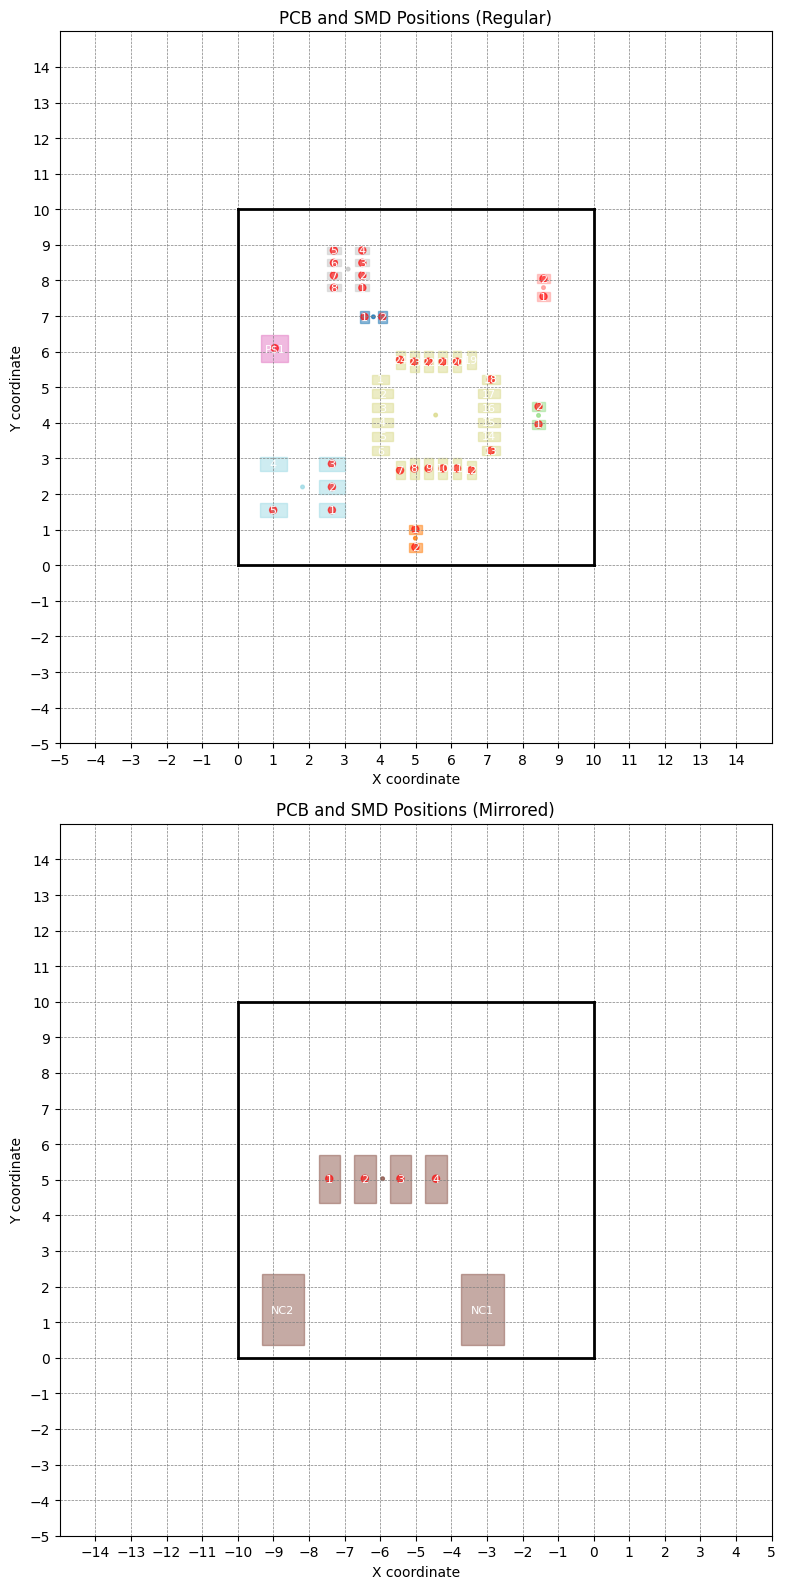

In [11]:
if __name__ == "__main__":
    # Load and parse the XML file for the specified IC
    folder_path = r"/Users/linkaiyuan/文件/PSU/Module_library"
    IC_name = "ICM-20948"
    file_name = f"{folder_path}\\{IC_name}\\{IC_name}.brd"

    file_name = r"/Users/linkaiyuan/Documents/EAGLE/projects/sparkfunmicropractis/SparkFun_IMU_Breakout_ICM-20948.brd"
    # Process the board file and plot
    board_info = process_board_file(file_name)
    print(board_info['signals'][1])

    plot_all_elements(border_segments=board_info['board dimension'],
                    elements=board_info['elements'],
                    ic_library=board_info['IC_library'],
                    signals=board_info['signals'],
                    view="both", legend=False, show_rectangles=True)


# Schematic (.sch) Extract Function

In [9]:
# Convert XML to dict
def xml_to_dict(element):
    """
    Recursively converts an XML element and its children into a dictionary.
    """
    # Convert attributes and text of the element to a dictionary
    result = {element.tag: {} if element.attrib else None}

    # Add element attributes to the dictionary
    if element.attrib:
        result[element.tag].update((key, value) for key, value in element.attrib.items())

    # Add element text to the dictionary if it exists
    if element.text and element.text.strip():
        text = element.text.strip()
        if result[element.tag]:
            result[element.tag]['text'] = text
        else:
            result[element.tag] = text

    # Convert child elements
    children = list(element)
    if children:
        child_dict = {}
        for child in children:
            child_result = xml_to_dict(child)
            if child.tag in child_dict:
                if isinstance(child_dict[child.tag], list):
                    child_dict[child.tag].append(child_result[child.tag])
                else:
                    child_dict[child.tag] = [child_dict[child.tag], child_result[child.tag]]
            else:
                child_dict.update(child_result)
        if result[element.tag]:
            result[element.tag].update(child_dict)
        else:
            result[element.tag] = child_dict

    return result


def get_deviceset_element(schematic_library, library_name, deviceset_name):
    """
    Extract the entire element of the deviceset from the schematic library.

    Args:
        schematic_library (list): List of libraries from the schematic XML.
        library_name (str): Name of the library containing the deviceset.
        deviceset_name (str): Name of the deviceset to extract.

    Returns:
        dict: The entire element of the deviceset, or None if not found.
    """
    # Find the library with the specified name
    library = next((lib for lib in schematic_library if lib['name'] == library_name), None)
    if not library:
        print(f"Library '{library_name}' not found.")
        return None
    

    # Find the deviceset within the library
    devicesets = library.get('devicesets', {}).get('deviceset', [])
    if not isinstance(devicesets, list):
        devicesets = [devicesets]

    deviceset = next((ds for ds in devicesets if ds['name'] == deviceset_name), None)
    if not deviceset:
        print(f"Deviceset '{deviceset_name}' not found in library '{library_name}'.")
        return None

    return deviceset


def extract_deviceset_info(deviceset_xml, device_name):
    """
    Extract deviceset name, symbol, and package from a deviceset XML.

    Args:
        deviceset_xml (dict): The deviceset XML as a dictionary.
        device_name (str): The name of the device to extract information for.

    Returns:
        dict: A dictionary containing the deviceset name, symbol, and package.
    """
    deviceset_info = {
        'name': deviceset_xml.get('name', 'Unknown'),
        'symbols': 'Unknown',
        'packages': ['Unknown']
    }

    # Extract gates and their symbols
    gates = deviceset_xml.get('gates', {}).get('gate', [])
    if isinstance(gates, dict):
        gates = [gates]
    if gates:
        deviceset_info['symbols'] = gates[0].get('symbol', 'Unknown')

    # Extract devices and their packages
    devices = deviceset_xml.get('devices', {}).get('device', [])
    if isinstance(devices, dict):
        devices = [devices]

    # Find the device with the specified device_name
    device_info = next((device for device in devices if device.get('name') == device_name), None)
    if device_info:
        deviceset_info['packages'] = device_info.get('package', 'Unknown')

    return deviceset_info


def map_part_to_deviceset(schematic_parts, schematic_library, schematic_instance):
    """
    Maps parts to their corresponding deviceset names, libraries, and additional attributes,
    including a list of instances with gate-specific information.

    Args:
        schematic_parts (list): List of parts containing deviceset, library, and value information.
        schematic_instance (list): List of instances containing part names and other attributes.

    Returns:
        dict: A dictionary where keys are part names and values are dictionaries containing deviceset, library,
              device, value, symbol, package, and a list of instances with gate-specific information.
    """
    # Create a mapping of part names to deviceset names, libraries, devices, and values
    # part_to_deviceset_and_library = {
    #     part['name']: {
    #         'deviceset': part['deviceset'],
    #         'library': part.get('library', 'Unknown'),
    #         'device': part.get('device', 'Unknown'),  # Include device information
    #         'value': '' if 'PowerSymbols' in part.get('library', 'Unknown') else part.get('value', ''),  # Conditionally include value information
    #         'package': 'Unknown',  # Initialize package information
    #         'instances': []  # Initialize an empty list for instances
    #     }
    #     for part in schematic_parts
    # }
    part_to_deviceset_and_library = {}

    for part in schematic_parts:
        part_name = part['name']
        part_info = {
            'deviceset': part['deviceset'],
            'library': part.get('library', 'Unknown'),
            'device': part.get('device', 'Unknown'),  # Include device information
            'value': '' if 'PowerSymbols' in part.get('library', 'Unknown') else part.get('value', ''),  # Conditionally include value information
            'package': 'Unknown',  # Initialize package information
            'instances': []  # Initialize an empty list for instances
        }


        # Optional attributes: add only if they exist
        optional_keys = ['library_urn', 'package3d_urn']
        for key in optional_keys:
            if key in part:
                part_info[key] = part[key]

        part_to_deviceset_and_library[part_name] = part_info
        
    # Map instances to their corresponding parts and add gate-specific information
    for instance in schematic_instance:
        
        part_name = instance['part']
        if part_name in part_to_deviceset_and_library:
            library_name = part_to_deviceset_and_library[part_name]['library']
            deviceset_name = part_to_deviceset_and_library[part_name]['deviceset']
            device_name = part_to_deviceset_and_library[part_name]['device']
            deviceset_element = get_deviceset_element(schematic_library, library_name, deviceset_name)

            # Find the symbol for the instance based on the gate name
            gate_name = instance.get('gate', 'Unknown')
            gates = deviceset_element.get('gates', {}).get('gate', [])
            if isinstance(gates, dict):
                gates = [gates]
            symbol = next((gate.get('symbol', 'Unknown') for gate in gates if gate.get('name') == gate_name), 'Unknown')

            instance_data = {
                'gate': gate_name,
                'x': instance.get('x', 'Unknown'),
                'y': instance.get('y', 'Unknown'),
                'rot': instance.get('rot', 'R0'),
                'symbol': symbol,
                "attribute": instance.get('attribute', [])
            }
            
            part_to_deviceset_and_library[part_name]['instances'].append(instance_data)

            # Update package information if not already set
            if part_to_deviceset_and_library[part_name]['package'] == 'Unknown':
                deviceset_info = extract_deviceset_info(deviceset_element, device_name)
                part_to_deviceset_and_library[part_name]['package'] = deviceset_info['packages']

    # for part in part_to_deviceset_and_library:
    #     print("part: ",part, part_to_deviceset_and_library[part])
        # print("--------------------------------------------------")

    return part_to_deviceset_and_library


def get_symbol_element_of_instance_from_library(library_xml, part_name, instance_gate_name, part_library):
    """
    Extract the symbol element from the library XML based on the part name and instance gate name.

    Args:
        library_xml (list): List of libraries from the schematic XML.
        part_name (str): Name of the part to extract the symbol for.
        instance_gate_name (str): Name of the gate to match the instance.
        part_library (dict): Dictionary containing part names mapped to their library, symbol, and other details.

    Returns:
        dict: The symbol element, or None if not found.
    """
    # Find the library name and symbol using the part name from the part library
    part_info = part_library.get(part_name)
    if not part_info:
        print(f"Part '{part_name}' not found in part library.")
        return None

    library_name = part_info.get('library')
    instances = part_info.get('instances', [])
    if not library_name or not instances:
        print(f"Library or instances not found for part '{part_name}'.")
        return None

    # Find the library with the specified name
    library = next((lib for lib in library_xml if lib['name'] == library_name), None)
    if not library:
        print(f"Library '{library_name}' not found.")
        return None

    # Extract symbols for the instance matching the specified gate name
    for instance in instances:
        
        if instance.get('gate') != instance_gate_name:
            continue
        

        symbol_name = instance.get('symbol')
        if not symbol_name:
            print(f"Symbol not found for instance in part '{part_name}'.")
            continue

        # Find the symbol in the library
        library_symbols = library.get('symbols', {}).get('symbol', [])
        if not isinstance(library_symbols, list):
            library_symbols = [library_symbols]

        symbol_element = next((sym for sym in library_symbols if sym['name'] == symbol_name), None)
        if not symbol_element:
            print(f"Symbol '{symbol_name}' not found in library '{library_name}'.")
            continue
        
        # print("instance:",instance)
        # print("------------------------")
        # Convert the symbol element into the desired dictionary format
        symbol_data = {
            'name': symbol_element.get('name', 'Unknown'),
            'wire': symbol_element.get('wire', []) if isinstance(symbol_element.get('wire', []), list) else [symbol_element.get('wire', [])],
            'text': instance.get('attribute', []) if isinstance(instance.get('attribute', []), list) else [instance.get('attribute', [])],
            'pin': symbol_element.get('pin', []) if isinstance(symbol_element.get('pin', []), list) else [symbol_element.get('pin', [])],
            'rectangle': symbol_element.get('rectangle', []) if isinstance(symbol_element.get('rectangle', []), list) else [symbol_element.get('rectangle', [])],
            'circle': symbol_element.get('circle', []) if isinstance(symbol_element.get('circle', []), list) else [symbol_element.get('circle', [])],
            'polygon': symbol_element.get('polygon', []) if isinstance(symbol_element.get('polygon', []), list) else [symbol_element.get('polygon', [])],
            'attribute': instance.get('attribute', [])
        }
        # print("symbol_data:",symbol_data)
        # print("--------------------------------------------------")
        return symbol_data
    
    print(f"No matching symbol found for gate '{instance_gate_name}' in part '{part_name}'.")
    return None

  
def retrieve_net_info(schematic_net):
    """
    Extract net information from the schematic net data.

    Args:
        schematic_net (list): List of nets from the schematic XML.

    Returns:
        dict: A dictionary where keys are net names and values are lists of segments,
              with each segment containing lists of pinrefs, wires, labels, and junctions.
    """
    net_info = {}

    # Ensure schematic_net is a list
    if not isinstance(schematic_net, list):
        schematic_net = [schematic_net]

    for net in schematic_net:
        net_name = net.get('name', 'Unknown')
        segments = net.get('segment', [])
        if not isinstance(segments, list):
            segments = [segments]

        # Process each segment
        processed_segments = []
        for segment in segments:
            processed_segment = {
                'pinref': segment.get('pinref', []) if isinstance(segment.get('pinref', []), list) else [segment.get('pinref', [])],
                'wire': segment.get('wire', []) if isinstance(segment.get('wire', []), list) else [segment.get('wire', [])],
                'label': segment.get('label', []) if isinstance(segment.get('label', []), list) else [segment.get('label', [])],
                'junction': segment.get('junction', []) if isinstance(segment.get('junction', []), list) else [segment.get('junction', [])]
            }
            processed_segments.append(processed_segment)

        net_info[net_name] = processed_segments

    return net_info



def process_schematic_file(file_path):
    """
    Process the board file and extract relevant information.

    Args:
        file_path (str): Path to the board file.

    Returns:
        dict: A dictionary containing board information.
    """
    tree = ET.parse(file_path)
    root = tree.getroot()
    xml_dict = xml_to_dict(root)

    # schematic_library = xml_dict['eagle']['drawing']['schematic']['libraries']['library']
    # schematic_parts = xml_dict['eagle']['drawing']['schematic']['parts']["part"]
    # schematic_instance = xml_dict['eagle']['drawing']['schematic']['sheets']["sheet"]['instances']['instance']
    # schematic_net = xml_dict['eagle']['drawing']['schematic']['sheets']["sheet"]['nets']['net']

        # Handle cases where instances, parts, or nets might not exist
    schematic_library = xml_dict.get('eagle', {}).get('drawing', {}).get('schematic', {}).get('libraries', {})
    if schematic_library is None:
        schematic_library = []
    else:
        schematic_library = schematic_library.get("library", []) or []
        if isinstance(schematic_library, dict):
            schematic_library = [schematic_library]

    schematic_parts = xml_dict.get('eagle', {}).get('drawing', {}).get('schematic', {}).get('parts', {})
    if schematic_parts is None:
        schematic_parts = []
    else:
        schematic_parts = schematic_parts.get("part", []) or []
        if isinstance(schematic_parts, dict):
            schematic_parts = [schematic_parts]

    # schematic_instance = xml_dict.get('eagle', {}).get('drawing', {}).get('schematic', {}).get('sheets', {}).get("sheet", {}).get('instances', {})
    schematic_instance = xml_dict.get('eagle', {})
    schematic_instance = schematic_instance.get('drawing', {})
    schematic_instance = schematic_instance.get('schematic', {}) 
    schematic_instance = schematic_instance.get('sheets', {})
    schematic_instance = schematic_instance.get("sheet", {}) 
    import json
    with open("text2.json", "w") as f:
        json.dump(schematic_instance, f, indent=2)
    schematic_instance = schematic_instance.get('instances', {})
    if schematic_instance is None:
        schematic_instance = []
    else:
        schematic_instance = schematic_instance.get("instance", []) or []
        if isinstance(schematic_instance, dict):
            schematic_instance = [schematic_instance]
    
    schematic_net = xml_dict.get('eagle', {}).get('drawing', {}).get('schematic', {}).get('sheets', {}).get("sheet", {}).get('nets', {})
    if schematic_net is None:
        schematic_net = []
    else:
        schematic_net = schematic_net.get("net", []) or []


    # print("schematic_library:", schematic_library)
    # print("schematic_parts:", schematic_parts)
    # print("schematic_instance:", schematic_instance)
    # print("schematic_net:", schematic_net)

    schematic_info = {}
    schematic_info['IC_library'] = schematic_library
    schematic_info['parts'] = map_part_to_deviceset(schematic_parts, schematic_library, schematic_instance)
    schematic_info['nets'] = retrieve_net_info(schematic_net) if schematic_net else {}


    # for net_name, segments in schematic_info['nets'].items():
    #     print("Net name:", net_name)
    #     print("Segments:")
    #     for segment in segments:
    #         print(segment)
    
    return schematic_info



# Example

In [30]:
if __name__ == "__main__":
    # <pinref part="C2" gate="G$1" pin="1"/>
    # <wire x1="53.34" y1="220.98" x2="53.34" y2="210.82" width="0.1524" layer="91"/>
    # Output elements from a file according the path
    # Load and parse the XML file for the specified IC
    folder_path = r"/Users/linkaiyuan/文件/PSU/products/Big_Easy_Driver/BigEasyDriver_v16a.sch"
    # folder_path = r"F:\GitHub\PCBEDA\sample PCB\sparkfun\simplified_Module_library"
    # IC_name = "ICM-20948"
    # sch_file_name = f"{folder_path}/{IC_name}/{IC_name}.sch"
    sch_file_name = folder_path
    # print("schematic file name:", sch_file_name)
    # sch_file_name = r"F:\GitHub\PCBEDA\sample PCB\custom\template.sch"
    # sch_file_name = r"F:\GitHub\PCBEDA\sample PCB\custom\temp_add.sch"
    schematic_info = process_schematic_file(sch_file_name)

In [57]:
# for i in schematic_info['IC_library']:
#     print("IC library:", i)
    # for smd in i.get('smd', []):
    #     print("SMD:", smd['name'], "Position:", smd['pos'])


import json


for part_name in schematic_info['parts'].items():
        # print(part_name[1]['deviceset'], part_name[1]['library'], part_name[1]['device'])
        # symbol = part_name[1]['instances'][0]['symbol']
        # new_name = f"name_{part_name[1]['library']}_{symbol}"
         print(part_name)
    # new_name = f"name_{part_name[1]['library']}_{part_name[1]['symbol']}"



# with open("text.json", "w") as f:
#     json.dump(schematic_info, f, indent=2)

('FRAME1', {'deviceset': 'FRAME-LETTER', 'library': 'SparkFun', 'device': '', 'value': '', 'package': 'Unknown', 'instances': [{'gate': 'G$1', 'x': '0', 'y': '0', 'rot': 'R0', 'symbol': 'LETTER_L', 'attribute': []}, {'gate': 'G$2', 'x': '147.32', 'y': '0', 'rot': 'R0', 'symbol': 'DOCFIELD', 'attribute': []}]})
('U1', {'deviceset': 'MPL3115A2', 'library': 'SparkFun-Sensors', 'device': 'LGA8', 'value': '', 'package': 'LGA8', 'instances': [{'gate': 'G$1', 'x': '144.78', 'y': '91.44', 'rot': 'R0', 'symbol': 'MPL3115A2', 'attribute': []}]})
('P+1', {'deviceset': 'VCC', 'library': 'SparkFun', 'device': '', 'value': '', 'package': 'Unknown', 'instances': [{'gate': '1', 'x': '127', 'y': '96.52', 'rot': 'R0', 'symbol': 'VCC2', 'attribute': []}]})
('GND1', {'deviceset': 'GND', 'library': 'SparkFun', 'device': '', 'value': '', 'package': 'Unknown', 'instances': [{'gate': '1', 'x': '124.46', 'y': '83.82', 'rot': 'R0', 'symbol': 'GND', 'attribute': []}]})
('C1', {'deviceset': 'CAP', 'library': 'Spa

# Get bounding box of schematic

In [10]:
import math

def update_bounding_box_from_item(item, min_x, max_x, min_y, max_y):
    """
    Updates the bounding box (min_x, max_x, min_y, max_y) based on the given item.
    (No changes in this function)
    """
    # ... (rest of the function is the same)
    if 'wire' in item:
        if isinstance(item['wire'], list):
            for wire_seg in item['wire']:
                x1 = float(wire_seg['x1'])
                y1 = float(wire_seg['y1'])
                x2 = float(wire_seg['x2'])
                y2 = float(wire_seg['y2'])
                min_x = min(min_x, x1, x2)
                max_x = max(max_x, x1, x2)
                min_y = min(min_y, y1, y2)
                max_y = max(max_y, y1, y2)
        elif isinstance(item['wire'], dict):
            wire_seg = item['wire']
            x1 = float(wire_seg['x1'])
            y1 = float(wire_seg['y1'])
            x2 = float(wire_seg['x2'])
            y2 = float(wire_seg['y2'])
            min_x = min(min_x, x1, x2)
            max_x = max(max_x, x1, x2)
            min_y = min(min_y, y1, y2)
            max_y = max(max_y, y1, y2)

    if 'junction' in item:
        if isinstance(item['junction'], list):
            for junction in item['junction']:
                x = float(junction['x'])
                y = float(junction['y'])
                min_x = min(min_x, x)
                max_x = max(max_x, x)
                min_y = min(min_y, y)
                max_y = max(max_y, y)
        elif isinstance(item['junction'], dict):
            junction = item['junction']
            x = float(junction['x'])
            y = float(junction['y'])
            min_x = min(min_x, x)
            max_x = max(max_x, x)
            min_y = min(min_y, y)
            max_y = max(max_y, y)

    if 'label' in item:
        if isinstance(item['label'], list):
            for label in item['label']:
                x = float(label['x'])
                y = float(label['y'])
                rot = label.get('rot', 'R0').upper()
                label_offset_x = 5 if rot != 'R180' else -5  # Adjust offset based on rotation
                label_x_adjusted = x + label_offset_x # Calculate adjusted x for label
                min_x = min(min_x, label_x_adjusted)
                max_x = max(max_x, label_x_adjusted)
                min_y = min(min_y, y)
                max_y = max(max_y, y)
        elif isinstance(item['label'], dict):
            label = item['label']
            x = float(label['x'])
            y = float(label['y'])
            rot = label.get('rot', 'R0').upper()
            label_offset_x = 5 if rot != 'R180' else -5  # Adjust offset based on rotation
            label_x_adjusted = x + label_offset_x # Calculate adjusted x for label
            min_x = min(min_x, label_x_adjusted)
            max_x = max(max_x, label_x_adjusted)
            min_y = min(min_y, y)
            max_y = max(max_y, y)

    return min_x, max_x, min_y, max_y

def get_bounding_box_for_symbol_instance(symbol_element, instance_x, instance_y, rot_angle_rad="R0", space=10):
    """
    Calculates the bounding box (xlim, ylim) for a single symbol instance.
    (No changes in this function)
    """
    min_x_symbol = float('inf')
    max_x_symbol = float('-inf')
    min_y_symbol = float('inf')
    max_y_symbol = float('-inf')

    rot_angle_deg = 0.0
    if rot_angle_rad.upper().startswith('R'):
        rot_angle_deg = float(rot_angle_rad[1:])
    elif rot_angle_rad.upper().startswith('MR'):
        rot_angle_deg = float(rot_angle_rad[2:])
    rot_angle_rad = math.radians(rot_angle_deg)

    elements_list = [
        symbol_element.get('pin', []),
        symbol_element.get('wire', []),
        symbol_element.get('rectangle', []),
        symbol_element.get('circle', []),
        symbol_element.get('polygon', []),
        symbol_element.get('text', [])
    ]

    for elements in elements_list:
        for element in elements:
            element_type = None
            if 'x1' in element and 'y1' in element and 'x2' in element and 'y2' in element and 'width' in element and 'layer' in element:
                element_type = 'wire'
            elif 'x' in element and 'y' in element and 'size' in element and 'layer' in element and 'font' in element and 'text' in element:
                element_type = 'text'
            elif 'name' in element and 'x' in element and 'y' in element and 'visible' in element and 'length' in element:
                element_type = 'pin'
            elif 'x1' in element and 'y1' in element and 'x2' in element and 'y2' in element:
                element_type = 'rectangle'
            elif 'x' in element and 'y' in element and 'radius' in element:
                element_type = 'circle'
            elif 'vertex' in element:
                element_type = 'polygon'


            element_min_x = float('inf')
            element_max_x = float('-inf')
            element_min_y = float('inf')
            element_max_y = float('-inf')

            if element_type == 'pin':
                px = float(element['x'])
                py = float(element['y'])
                rotated_x = instance_x + (px * math.cos(rot_angle_rad) - py * math.sin(rot_angle_rad))
                rotated_y = instance_y + (px * math.sin(rot_angle_rad) + py * math.cos(rot_angle_rad))
                element_min_x = min(element_min_x, rotated_x)
                element_max_x = max(element_max_x, rotated_x)
                element_min_y = min(element_min_y, rotated_y)
                element_max_y = max(element_max_y, rotated_y)

            elif element_type == 'wire':
                x1 = float(element['x1'])
                y1 = float(element['y1'])
                x2 = float(element['x2'])
                y2 = float(element['y2'])
                rotated_x1 = instance_x + (x1 * math.cos(rot_angle_rad) - y1 * math.sin(rot_angle_rad))
                rotated_y1 = instance_y + (x1 * math.sin(rot_angle_rad) + y1 * math.cos(rot_angle_rad))
                rotated_x2 = instance_x + (x2 * math.cos(rot_angle_rad) - y2 * math.sin(rot_angle_rad))
                rotated_y2 = instance_y + (x2 * math.sin(rot_angle_rad) + y2 * math.cos(rot_angle_rad))
                element_min_x = min(element_min_x, rotated_x1, rotated_x2)
                element_max_x = max(element_max_x, rotated_x1, rotated_x2)
                element_min_y = min(element_min_y, rotated_y1, rotated_y2)
                element_max_y = max(element_max_y, rotated_y1, rotated_y2)

            elif element_type == 'rectangle':
                x1 = float(element['x1'])
                y1 = float(element['y1'])
                x2 = float(element['x2'])
                y2 = float(element['y2'])
                rect_points = [(x1, y1), (x2, y1), (x2, y2), (x1, y2)]
                for px, py in rect_points:
                    rotated_x = instance_x + (px * math.cos(rot_angle_rad) - py * math.sin(rot_angle_rad))
                    rotated_y = instance_y + (px * math.sin(rot_angle_rad) + py * math.cos(rot_angle_rad))
                    element_min_x = min(element_min_x, rotated_x)
                    element_max_x = max(element_max_x, rotated_x)
                    element_min_y = min(element_min_y, rotated_y)
                    element_max_y = max(element_max_y, rotated_y)

            elif element_type == 'circle':
                x_center = float(element['x'])
                y_center = float(element['y'])
                radius = float(element['radius'])
                # Circle's bounds are center +/- radius in both directions (approximate rotation)
                element_min_x = min(element_min_x, instance_x + ( (x_center - radius) * math.cos(rot_angle_rad) - (y_center + radius) * math.sin(rot_angle_rad)) ) # Approximate
                element_max_x = max(element_max_x, instance_x + ( (x_center + radius) * math.cos(rot_angle_rad) - (y_center - radius) * math.sin(rot_angle_rad)) ) # Approximate
                element_min_y = min(element_min_y, instance_y + ( (x_center - radius) * math.sin(rot_angle_rad) + (y_center - radius) * math.cos(rot_angle_rad)) ) # Approximate
                element_max_y = max(element_max_y, instance_y + ( (x_center + radius) * math.sin(rot_angle_rad) + (y_center + radius) * math.cos(rot_angle_rad)) ) # Approximate

            elif element_type == 'polygon':
                poly_vertices = element.get('vertex', [])
                for v in poly_vertices:
                    px = float(v['x'])
                    py = float(v['y'])
                    rotated_x = instance_x + (px * math.cos(rot_angle_rad) - py * math.sin(rot_angle_rad))
                    rotated_y = instance_y + (px * math.sin(rot_angle_rad) + py * math.cos(rot_angle_rad))
                    element_min_x = min(element_min_x, rotated_x)
                    element_max_x = max(element_max_x, rotated_x)
                    element_min_y = min(element_min_y, rotated_y)
                    element_max_y = max(element_max_y, rotated_y)

            elif element_type == 'text': # Treat text as point for now
                text_x = float(element['x'])
                text_y = float(element['y'])
                rotated_x = instance_x + (text_x * math.cos(rot_angle_rad) - text_y * math.sin(rot_angle_rad))
                rotated_y = instance_y + (text_x * math.sin(rot_angle_rad) + text_y * math.cos(rot_angle_rad))
                element_min_x = min(element_min_x, rotated_x)
                element_max_x = max(element_max_x, rotated_x)
                element_min_y = min(element_min_y, rotated_y)
                element_max_y = max(element_max_y, rotated_y)

            min_x_symbol = min(min_x_symbol, element_min_x)
            max_x_symbol = max(max_x_symbol, element_max_x)
            min_y_symbol = min(min_y_symbol, element_min_y)
            max_y_symbol = max(max_y_symbol, element_max_y)

    if min_x_symbol == float('inf'): # No elements found
        return ((instance_x, instance_x + 200), (instance_y, instance_y + 200)) # Return a default range around instance position
    else:
        xlim = (min_x_symbol-space, max_x_symbol+space)
        ylim = (min_y_symbol-space, max_y_symbol+space)
        return (xlim, ylim)

def get_schematic_bounding_box_from_schematic_info(schematic_info):
    """
    Calculates the bounding box (xlim, ylim) that encompasses all elements (parts and nets)
    in the schematic_info. This version utilizes get_bounding_box_for_symbol_instance for parts.

    Args:
        schematic_info (dict): The schematic information dictionary containing 'parts', 'nets', and 'IC_library'.

    Returns:
        tuple: A tuple containing (xlim, ylim) as tuples, e.g., ((min_x, max_x), (min_y, max_y)).
               Returns None if schematic_info is missing 'parts', 'nets', or 'IC_library'.
    """
    parts_info = schematic_info.get('parts')
    ic_library = schematic_info.get('IC_library')
    nets_info = schematic_info.get('nets')

    if not parts_info or not ic_library:
        return None  # Missing essential schematic data

    min_x_overall = float('inf')
    max_x_overall = float('-inf')
    min_y_overall = float('inf')
    max_y_overall = float('-inf')

    # --- Calculate bounding box for parts using get_bounding_box_for_symbol_instance ---
    if parts_info:
        for part_name, part_data in parts_info.items():
            for instance in part_data.get('instances', []):
                gate_instance = instance.get('gate', '') # Handle cases where gate might be missing
                symbol_element = get_symbol_element_of_instance_from_library(
                    ic_library, part_name, gate_instance, parts_info
                )

                if symbol_element:
                    rot_instance = instance['rot']
                    x_instance = float(instance['x'])
                    y_instance = float(instance['y'])

                    symbol_instance_bbox = get_bounding_box_for_symbol_instance(
                        symbol_element, x_instance, y_instance, rot_instance
                    )
                    xlim_instance, ylim_instance = symbol_instance_bbox

                    min_x_overall = min(min_x_overall, xlim_instance[0])
                    max_x_overall = max(max_x_overall, xlim_instance[1])
                    min_y_overall = min(min_y_overall, ylim_instance[0])
                    max_y_overall = max(max_y_overall, ylim_instance[1])


    # --- Calculate bounding box for nets (no changes here) ---
    if nets_info:
        for net_name, net_data in nets_info.items():
            if isinstance(net_data, list):
                for item in net_data:
                    min_x_overall, max_x_overall, min_y_overall, max_y_overall = update_bounding_box_from_item(
                        item, min_x_overall, max_x_overall, min_y_overall, max_y_overall
                    )
            elif isinstance(net_data, dict): # if net_data is a dict, assume it's like item structure
                min_x_overall, max_x_overall, min_y_overall, max_y_overall = update_bounding_box_from_item(
                    net_data, min_x_overall, max_x_overall, min_y_overall, max_y_overall
                )

    # print("min_x_overall:", min_x_overall, "max_x_overall:", max_x_overall)
    if min_x_overall == float('inf'): # No elements found
        return ((0,100), (0,100)) # Return a default range if no elements are found
    else:
        xlim = (min_x_overall - 5, max_x_overall + 5) # Add some margin
        ylim = (min_y_overall - 5, max_y_overall + 5) # Add some margin
        return (xlim, ylim)
    


# Example

In [22]:
if __name__ == "__main__":
    bounding_box = get_schematic_bounding_box_from_schematic_info(schematic_info)

    print("bounding_box:",bounding_box)


bounding_box: ((-15.0, 446.8), (-15.0, 294.4))


# draw schematic 

In [11]:
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Circle, Arc, Polygon
import math

# Switch to a backend that supports pop-out windows (like Qt5Agg, TkAgg, MacOSX)
# You might need to install the backend if you don't have it (e.g., pip install pyqt5 for Qt5Agg)
matplotlib.use('Qt5Agg') # Or try 'TkAgg' or 'MacOSX'

def draw_polygons(polygons, x=0, y=0, rot_angle_rad='R0', color='red', fill=False, facecolor=None):
    """
    Draws a list of polygons from EAGLE polygon dictionaries with rotation.

    Each polygon dictionary should have:
      - 'width': the line width (string convertible to float)
      - 'layer': (optional) the layer (not used here)
      - 'vertex': a list of dictionaries, each with keys 'x' and 'y'

    Parameters:
      polygons (list): List of polygon dictionaries.
      x (float): X-coordinate of the center.
      y (float): Y-coordinate of the center.
      rot_angle_rad (float): Rotation angle in radians.
      color (str): Color for the polygon edge.
      fill (bool): Whether to fill the polygon.
      facecolor (str): Color to fill the polygon (if fill is True).
    """
    rot_angle_deg = 0.0
    if rot_angle_rad.upper().startswith('R'):
        rot_angle_deg = float(rot_angle_rad[1:])
    elif rot_angle_rad.upper().startswith('MR'):
        rot_angle_deg = float(rot_angle_rad[2:])
    rot_angle_rad = math.radians(rot_angle_deg)

    ax = plt.gca()
    for poly in polygons:
        # Extract vertices as a list of (x,y) tuples and apply rotation
        vertices = poly.get('vertex', [])
        rotated_pts = []
        for v in vertices:
            px = float(v['x'])
            py = float(v['y'])
            rotated_x = x + (px * math.cos(rot_angle_rad) - py * math.sin(rot_angle_rad))
            rotated_y = y + (px * math.sin(rot_angle_rad) + py * math.cos(rot_angle_rad))
            rotated_pts.append((rotated_x, rotated_y))

        # Get the line width from the polygon dictionary
        width = float(poly.get('width', '0.1524'))

        # Create a Polygon patch: closed, optionally filled, with specified line width.
        poly_patch = Polygon(
            rotated_pts,
            closed=True,
            fill=fill,
            facecolor=facecolor if fill and facecolor is not None else 'none',
            edgecolor=color,
            linewidth=width
        )
        ax.add_patch(poly_patch)

def draw_circle(circle_data, x=0, y=0, rot_angle_rad='R0'):
    """
    Draws a circle with rotation.
    """
    rot_angle_deg = 0.0
    if rot_angle_rad.upper().startswith('R'):
        rot_angle_deg = float(rot_angle_rad[1:])
    elif rot_angle_rad.upper().startswith('MR'):
        rot_angle_deg = float(rot_angle_rad[2:])
    rot_angle_rad = math.radians(rot_angle_deg)
    
    # Extract circle parameters
    x_center = float(circle_data['x'])
    y_center = float(circle_data['y'])
    radius   = float(circle_data['radius'])
    line_w   = float(circle_data['width'])

    # Apply rotation to the circle center
    rotated_x_center = x + (x_center * math.cos(rot_angle_rad) - y_center * math.sin(rot_angle_rad))
    rotated_y_center = y + (x_center * math.sin(rot_angle_rad) + y_center * math.cos(rot_angle_rad))


    # Create a Circle patch (unfilled by default)
    circle_patch = Circle(
        (rotated_x_center, rotated_y_center),
        radius,
        fill=False,         # set fill=True if you want a filled circle
        linewidth=line_w,
        edgecolor='red'     # choose any color you prefer
    )

    # Add to the current axes
    plt.gca().add_patch(circle_patch)

def draw_pins(pins,  x=0, y=0, rot_angle_rad='R0'):
    """
    Draws pins with rotation.
    """
    rot_angle_deg = 0.0
    if rot_angle_rad.upper().startswith('R'):
        rot_angle_deg = float(rot_angle_rad[1:])
    elif rot_angle_rad.upper().startswith('MR'):
        rot_angle_deg = float(rot_angle_rad[2:])
    rot_angle_rad = math.radians(rot_angle_deg)
    
    # Define the mapping from length strings to extension distances
    length_map = {
        'point': 0.0,
        'short': 2.54,
        'middle': 2.54 * 2,
        'long': 2.54 * 3
    }

    for pin in pins:
        # Get base coordinates
        x_base = float(pin['x'])
        y_base = float(pin['y'])

        # Apply rotation to the pin base
        rotated_x_base = x + (x_base * math.cos(rot_angle_rad) - y_base * math.sin(rot_angle_rad))
        rotated_y_base = y + (x_base * math.sin(rot_angle_rad) + y_base * math.cos(rot_angle_rad))
        x_base = rotated_x_base
        y_base = rotated_y_base


        # Determine the extension distance based on the pin's 'length'
        length_type = pin.get('length', 'short').lower()
        extension = length_map.get(length_type, 2.54)  # default to short if not recognized

        # Determine the rotation angle from the pin's 'rot' value and add symbol rotation
        rot_pin_str = pin.get('rot', 'R0')
        pin_angle_deg = 0
        if rot_pin_str.upper().startswith('R'):
            pin_angle_deg = float(rot_pin_str[1:])
        pin_angle_rad = math.radians(pin_angle_deg) + rot_angle_rad


        # Compute the endpoint of the pin line
        x_end = x_base + extension * math.cos(pin_angle_rad)
        y_end = y_base + extension * math.sin(pin_angle_rad)

        # Draw the pin line
        plt.plot([x_base, x_end], [y_base, y_end], color='red', lw=1)
        # Draw a marker at the base of the pin
        plt.scatter([x_base], [y_base], color='blue', zorder=5)

        # Annotate the pin if it is visible as 'pin' or 'both'
        # if pin.get('visible', '').lower() in ['pin', 'both',"off",'pad']:
        #     plt.annotate(pin['name'], (x_base, y_base), textcoords="offset points",
        #          xytext=(0, 10), ha='center')
        plt.annotate(pin['name'], (x_base, y_base), textcoords="offset points",
                xytext=(0, 10), ha='center')
        

def draw_rectangle(rect_data,  x=0, y=0, rot_angle_rad='R0', color='red', alpha=1.0):
    """
    Draw a rectangle with rotation.
    """
    rot_angle_deg = 0.0
    if rot_angle_rad.upper().startswith('R'):
        rot_angle_deg = float(rot_angle_rad[1:])
    elif rot_angle_rad.upper().startswith('MR'):
        rot_angle_deg = float(rot_angle_rad[2:])
    rot_angle_rad = math.radians(rot_angle_deg)
    
    x1 = float(rect_data['x1'])
    y1 = float(rect_data['y1'])
    x2 = float(rect_data['x2'])
    y2 = float(rect_data['y2'])

    # Rotate the rectangle corners
    rotated_x1 = x + (x1 * math.cos(rot_angle_rad) - y1 * math.sin(rot_angle_rad))
    rotated_y1 = y + (x1 * math.sin(rot_angle_rad) + y1 * math.cos(rot_angle_rad))
    rotated_x2 = x + (x2 * math.cos(rot_angle_rad) - y2 * math.sin(rot_angle_rad))
    rotated_y2 = y + (x2 * math.sin(rot_angle_rad) + y2 * math.cos(rot_angle_rad))

    left   = min(rotated_x1, rotated_x2)
    bottom = min(rotated_y1, rotated_y2)
    width  = abs(rotated_x2 - rotated_x1) # width and height are calculated after rotation
    height = abs(rotated_y2 - rotated_y1)


    rect_patch = Rectangle(
        (left, bottom),
        width,
        height,
        fill=True,
        facecolor=color,
        edgecolor='none',   # no edge
        alpha=alpha
    )
    plt.gca().add_patch(rect_patch)

def draw_wire_eagle_style(wire,  x=0, y=0, rot_angle_rad='R0'):
    """
    Draws a 'wire' with rotation.
    """
    rot_angle_deg = 0.0
    if rot_angle_rad.upper().startswith('R'):
        rot_angle_deg = float(rot_angle_rad[1:])
    elif rot_angle_rad.upper().startswith('MR'):
        rot_angle_deg = float(rot_angle_rad[2:])
    rot_angle_rad = math.radians(rot_angle_deg)
    
    # Extract endpoints
    x1_orig = float(wire['x1']) # keep original for center calculation
    y1_orig = float(wire['y1'])
    x2_orig = float(wire['x2'])
    y2_orig = float(wire['y2'])

    # Rotate wire endpoints
    rotated_x1 = x + (x1_orig * math.cos(rot_angle_rad) - y1_orig * math.sin(rot_angle_rad))
    rotated_y1 = y + (x1_orig * math.sin(rot_angle_rad) + y1_orig * math.cos(rot_angle_rad))
    rotated_x2 = x + (x2_orig * math.cos(rot_angle_rad) - y2_orig * math.sin(rot_angle_rad))
    rotated_y2 = y + (x2_orig * math.sin(rot_angle_rad) + y2_orig * math.cos(rot_angle_rad))
    x1 = rotated_x1
    y1 = rotated_y1
    x2 = rotated_x2
    y2 = rotated_y2


    # Check for a 'curve' parameter
    c = wire.get('curve', 0)
    curve_deg = float(c)

    # If no curve (or zero), draw a straight line
    if abs(curve_deg) < 1e-9:
        plt.plot([x1, x2], [y1, y2], 'r-')
        return

    # 1) Compute chord length
    chord_len = math.hypot(x2_orig - x1_orig, y2_orig - y1_orig) # use original points
    if chord_len < 1e-9:
        # Degenerate case: start == end
        return

    # 2) Convert curve to radians (absolute value)
    theta = math.radians(abs(curve_deg))

    # 3) Compute radius
    R = chord_len / (2.0 * math.sin(theta / 2.0))

    # 4) Find the midpoint of the chord (using original points)
    mx_orig = (x1_orig + x2_orig) / 2.0
    my_orig = (y1_orig + y2_orig) / 2.0

    # 5) Distance from midpoint to center
    d = math.sqrt(R*R - (chord_len / 2.0)**2)

    # 6) Compute the direction perpendicular to the chord (using original points)
    vx_orig = x2_orig - x1_orig
    vy_orig = y2_orig - y1_orig
    nx_orig = -vy_orig
    ny_orig =  vx_orig
    length_n_orig = math.hypot(nx_orig, ny_orig)
    nx_orig /= length_n_orig
    ny_orig /= length_n_orig

    # 7) Depending on the sign of 'curve', pick which side of the chord the center is on (using original points)
    if curve_deg > 0:
        cx_orig = mx_orig + d * nx_orig
        cy_orig = my_orig + d * ny_orig
    else:
        cx_orig = mx_orig - d * nx_orig
        cy_orig = my_orig - d * ny_orig

    # Rotate the arc center - now rotate the original center, and then translate
    rotated_cx = x + (cx_orig * math.cos(rot_angle_rad) - cy_orig * math.sin(rot_angle_rad))
    rotated_cy = y + (cx_orig * math.sin(rot_angle_rad) + cy_orig * math.cos(rot_angle_rad))
    cx = rotated_cx
    cy = rotated_cy


    # 8) Compute start/end angles for the arc in degrees (using rotated endpoints and rotated center)
    start_angle = math.degrees(math.atan2(y1 - cy, x1 - cx))
    end_angle   = math.degrees(math.atan2(y2 - cy, x2 - cx))

    def normalize_angle(a):
        return a % 360

    start_angle = normalize_angle(start_angle)
    end_angle   = normalize_angle(end_angle)

    if curve_deg > 0:
        diff = end_angle - start_angle
        if diff < 0:
            diff += 360
        if abs(diff - curve_deg) > 1e-3:
            if diff < curve_deg:
                end_angle += 360
            else:
                end_angle -= 360
    else:
        temp = start_angle
        start_angle = end_angle
        end_angle   = temp


    # 9) Finally, draw the arc
    arc = Arc(
        (cx, cy),           # center
        2*R, 2*R,           # width, height
        angle=0,            # rotation of the whole arc ellipse (0 for a circle)
        theta1=start_angle, # start angle in degrees
        theta2=end_angle,   # end angle in degrees
        color='red'
    )
    plt.gca().add_patch(arc)


def draw_text_eagle_style(text_element, x=0, y=0, rot_angle_rad='R0'):
    """
    Draws text based on the provided text element, with optional position offset and rotation.
    """
    print("text_element:",text_element)
    # Extract attributes
    text_x_orig = float(text_element['x'])
    text_y_orig = float(text_element['y'])
    text_size = float(text_element['size'])*10
    text_content = text_element['name']

    # if text_content.upper() in ['NAME','VALUE']:
    #     return 
    
    # Rotation
    rot_angle_rad_val = 0
    if rot_angle_rad != 'R0':
        if rot_angle_rad.startswith('R'):
            rot_angle_deg = float(rot_angle_rad[1:])
            rot_angle_rad_val = math.radians(rot_angle_deg)
        else: # Assume direct radian value if not 'R' prefix, though 'R' prefix is eagle style
            try:
                rot_angle_rad_val = float(rot_angle_rad)
            except ValueError:
                rot_angle_rad_val = 0 # Default to 0 if parsing fails

    # Rotate text position
    rotated_x = x + (text_x_orig * math.cos(rot_angle_rad_val) - text_y_orig * math.sin(rot_angle_rad_val))
    rotated_y = y + (text_x_orig * math.sin(rot_angle_rad_val) + text_y_orig * math.cos(rot_angle_rad_val))
    final_x = rotated_x
    final_y = rotated_y

    rotation_deg = math.degrees(rot_angle_rad_val)

    # Draw text using plt.text
    plt.text(final_x, final_y, text_content, fontsize=text_size, ha='center', va='center', rotation=rotation_deg, color='red') # ha and va for centering similar to eagle

    return

def draw_part_attributes(attributes, part_name="Unknown", part_value="Unknown", symbol_name="Unknown"):
    """
    Draws part attributes such as name and value on the plot.

    Args:
        attributes (list or dict): List or dictionary of attributes to draw.
        x (float): X-coordinate of the center.
        y (float): Y-coordinate of the center.
        rot_angle_rad (float): Rotation angle in radians.
        part_name (str): Name of the part.
        part_value (str): Value of the part.
        symbol_name (str): Name of the symbol.
    """

    if not attributes:  # Check if attributes is empty
        return

    if isinstance(attributes, dict):  # Convert dictionary to list for uniform processing
        attributes = [attributes]

    for attribute in attributes:
        attr_name = attribute.get('name', '').upper()
        attr_x = float(attribute.get('x', 0))
        attr_y = float(attribute.get('y', 0))
        attr_size = float(attribute.get('size', 1.0))
        attr_rot = attribute.get('rot', 'R0')

        # Apply rotation to attribute coordinates
        attr_rot_deg = 0.0
        if attr_rot.upper().startswith('R'):
            attr_rot_deg = float(attr_rot[1:])


        if "GND" in symbol_name or "GND" in part_name:
            continue

        # Determine if the attribute is for part name or part value
        if attr_name == "NAME" and part_name != "Unknown":
            plt.text(attr_x, attr_y, part_name, fontsize=attr_size * 10, ha='center', va='center', 
                        rotation=attr_rot_deg, color='blue')
        elif attr_name == "VALUE":
            # Use symbol_name as part_value if part_value is unknown
            display_value = part_value if part_value not in ["Unknown", ""] else symbol_name
            plt.text(attr_x, attr_y, display_value, fontsize=attr_size * 10, ha='center', va='center', 
                        rotation=attr_rot_deg, color='green')
        elif  "GND" != symbol_name:
            print(f"Drawing attribute '{attr_name}' for part '{part_name}'")
            plt.text(attr_x, attr_y, attr_name, fontsize=attr_size * 10, ha='center', va='center', 
                        rotation=attr_rot_deg, color='red')
                

def visualize_wires_junctions(data, net_name):
    """
    Visualizes wires, junctions, and labels from the given data using matplotlib.
    """
    ax = plt.gca()  # Get current axes
    ax.yaxis.set_inverted(True)  # Invert y-axis here, within the function itself
    ax.set_aspect('equal', adjustable='box')

    min_x, max_x, min_y, max_y = float('inf'), float('-inf'), float('inf'), float('-inf')
    data_found = False  # Flag to track if any wire/junction data was processed

    for item in data:
        if 'wire' in item:
            data_found = True  # Set flag to True because we found wire data
            if isinstance(item['wire'], list):
                for wire_seg in item['wire']:
                    x1 = float(wire_seg['x1'])
                    y1 = float(wire_seg['y1'])
                    x2 = float(wire_seg['x2'])
                    y2 = float(wire_seg['y2'])
                    width = float(wire_seg['width']) if 'width' in wire_seg else 0.1524
                    layer = wire_seg['layer'] if 'layer' in wire_seg else '91'
                    ax.plot([x1, x2], [y1, y2], linewidth=width * 10, color='green')
                    min_x = min(min_x, x1, x2)
                    max_x = max(max_x, x1, x2)
                    min_y = min(min_y, y1, y2)
                    max_y = max(max_y, y1, y2)
            elif isinstance(item['wire'], dict):
                wire_seg = item['wire']
                x1 = float(wire_seg['x1'])
                y1 = float(wire_seg['y1'])
                x2 = float(wire_seg['x2'])
                y2 = float(wire_seg['y2'])
                width = float(wire_seg['width']) if 'width' in wire_seg else 0.1524
                layer = wire_seg['layer'] if 'layer' in wire_seg else '91'
                ax.plot([x1, x2], [y1, y2], linewidth=width * 20, color='green')
                min_x = min(min_x, x1, x2)
                max_x = max(max_x, x1, x2)
                min_y = min(min_y, y1, y2)
                max_y = max(max_y, y1, y2)

        if 'junction' in item:
            data_found = True  # Set flag to True because we found junction data
            if isinstance(item['junction'], list):
                for junction in item['junction']:
                    x = float(junction['x'])
                    y = float(junction['y'])
                    ax.plot(x, y, marker='o', markersize=5, color='green')
                    min_x = min(min_x, x)
                    max_x = max(max_x, x)
                    min_y = min(min_y, y)
                    max_y = max(max_y, y)
            elif isinstance(item['junction'], dict):
                junction = item['junction']
                x = float(junction['x'])
                y = float(junction['y'])
                ax.plot(x, y, marker='o', markersize=5, color='green')
                min_x = min(min_x, x)
                max_x = max(max_x, x)
                min_y = min(min_y, y)
                max_y = max(max_y, y)

        if 'label' in item:
            data_found = True  # Set flag to True because we found label data
            if isinstance(item['label'], list):
                for label in item['label']:
                    x = float(label['x'])
                    y = float(label['y'])
                    font_size = float(label.get('size', 8)) * 15  # Dynamically get font size, default to 8
                    rot = label.get('rot', 'R0').upper()
                    label_offset_x = 5 if rot != 'R180' else -5  # Adjust offset based on rotation
                    label_offset_y = 0  # No distance for y-coordinate
                    ax.text(x + label_offset_x, y + label_offset_y, net_name, fontsize=font_size, ha='center', va='center', color='gray')
                    min_x = min(min_x, x + label_offset_x)
                    max_x = max(max_x, x + label_offset_x)
                    min_y = min(min_y, y)
                    max_y = max(max_y, y)
            elif isinstance(item['label'], dict):
                label = item['label']
                x = float(label['x'])
                y = float(label['y'])
                font_size = float(label.get('size', 8)) * 15  # Dynamically get font size, default to 8
                rot = label.get('rot', 'R0').upper()
                label_offset_x = 5 if rot != 'R180' else -5  # Adjust offset based on rotation
                label_offset_y = 0  # No distance for y-coordinate
                ax.text(x + label_offset_x, y + label_offset_y, net_name, fontsize=font_size, ha='center', va='center', color='gray')
                min_x = min(min_x, x + label_offset_x)
                max_x = max(max_x, x + label_offset_x)
                min_y = min(min_y, y)
                max_y = max(max_y, y)

    if data_found:  # Only set limits and labels if data was found
        ax.set_xlim(min_x - 5, max_x + 5)
        ax.set_ylim(min_y - 5, max_y + 5)
        ax.set_xlabel("X Coordinate")
        ax.set_ylabel("Y Coordinate")
        ax.set_title("Visualization of Wires, Junctions, and Labels")
        plt.grid(True, linestyle='--', alpha=0.6)
    else:
        ax.text(0.5, 0.5, "No wire, junction, or label data to display", ha='center', va='center', fontsize=12, color='gray')  # Display message if no data


# Function to visualize symbol with rotation
def visualize_symbol_from_dict(symbol_data, x=0, y=0, rot_angle_rad='R0', part_name="Unknown", part_value="Unknown",symbol_name="Unknown"):
    """
    Visualizes the symbol data with rotation.

    Args:
        symbol_data (dict): Dictionary containing symbol information.
        x (float): X-coordinate of the center.
        y (float): Y-coordinate of the center.
        rot (str): Rotation of the symbol, e.g., 'R90', 'R0', 'R270'.
    """
    # Convert rotation string to radians
    # rot_angle_deg = 0.0
    # if rot.upper().startswith('R'):
    #     rot_angle_deg = float(rot[1:])
    # rot_angle_rad = math.radians(rot_angle_rad)

    # Extract symbol elements
    pins = symbol_data.get('pin', [])
    # print("pins:",pins)
    wires = symbol_data.get('wire', [])
    rectangles = symbol_data.get('rectangle', [])
    circles = symbol_data.get('circle', [])
    polygons = symbol_data.get('polygon', [])
    attributes = symbol_data.get('attribute', [])


    # print(symbol_data['name'],"text:",text)
    # if symbol_data['name'] == 'FIDUCIAL':
    #     for text_element in text:
    #         draw_text_eagle_style(text_element, x, y, rot_angle_rad)

    # Plot circles
    for circle in circles:
        draw_circle(circle, x, y, rot_angle_rad)

    # Plot polygons
    if polygons:
        draw_polygons(polygons, x, y, rot_angle_rad, color='red', fill=True, facecolor='red')

    # Plot pins
    draw_pins(pins, x, y, rot_angle_rad)

    # Draw wires
    for wire in wires:
        draw_wire_eagle_style(wire, x, y, rot_angle_rad)

    # Draw rectangles
    for rect_data in rectangles:
        draw_rectangle(rect_data, x, y, rot_angle_rad, color='red', alpha=1.0)

    
    draw_part_attributes(attributes, part_name, part_value, symbol_name)


def visualize_schematic(schematic_file_path):
    """
    Visualizes the schematic based on the provided schematic_info.

    Args:
        schematic_info (dict): Dictionary containing schematic information, including parts and nets.
    """
    plt.figure(figsize=(10, 8))  # Create figure and axes
    ax = plt.gca()  # Get current axes
    # print("Parts in schematic:", schematic_info['parts'])

    schematic_info = process_schematic_file(schematic_file_path)  # Parse the schematic file
    # Visualize parts
    for part_name, part_data in schematic_info['parts'].items():
        part_value = part_data.get('value', 'Unknown')

        for instance in part_data.get('instances', []):
            symbol_name = instance['symbol']
            x = float(instance['x'])
            y = float(instance['y'])
            rot = instance['rot']
            gate = instance['gate']

            symbol_element = get_symbol_element_of_instance_from_library(
                schematic_info['IC_library'], part_name, gate, schematic_info['parts']
            )
            # print("part_data:", symbol_name)
            if symbol_element:
                visualize_symbol_from_dict(symbol_element, x, y, rot, part_name, part_value, symbol_name)

    # Visualize nets
    for net_name, net_data in schematic_info['nets'].items():
        visualize_wires_junctions(net_data, net_name)

    # Calculate and display bounding box
    bounding_box = get_schematic_bounding_box_from_schematic_info(schematic_info)
    # print("Bounding box:", bounding_box)

    if bounding_box:
        xlim, ylim = bounding_box
        # print(f"Bounding Box for entire schematic: xlim = {xlim}, ylim = {ylim}")
        ax.set_xlim(xlim)
        ax.set_ylim(ylim)

        # Draw bounding box in red dashed line
        rect = Rectangle(
            (xlim[0], ylim[0]),  # Bottom-left corner
            xlim[1] - xlim[0],   # Width
            ylim[1] - ylim[0],   # Height
            linewidth=10,
            edgecolor='red',
            linestyle='--',
            facecolor='none'
        )
        ax.add_patch(rect)
    else:
        print("Empty schematic.")

    plt.axis('equal') 
    # Add labels, legend, and grid
    plt.xlabel('X Coordinate')
    plt.ylabel('Y Coordinate')
    plt.legend()
    plt.grid(True)
    # Show the schematic
    plt.show()



ImportError: Failed to import any of the following Qt binding modules: PyQt5, PySide2

# Example

In [6]:
if __name__ == "__main__":
    # Load and parse the XML file for the specified IC
    folder_path = r"F:\GitHub\PCBEDA\sample PCB\sparkfun\Module_library"
    # folder_path = r"F:\GitHub\PCBEDA\sample PCB\sparkfun\simplified_Module_library"
    IC_name = "ICM-20948"
    sch_file_name = f"{folder_path}\\{IC_name}\\{IC_name}.sch"
    # sch_file_name = r"F:\GitHub\PCBEDA\sample PCB\custom\template.sch"
    visualize_schematic(sch_file_name)

Drawing attribute 'LAST_DATE_TIME' for part 'FRAME2'
Drawing attribute 'SHEET' for part 'FRAME2'
Drawing attribute 'DRAWING_NAME' for part 'FRAME2'
Drawing attribute 'DESIGNER' for part 'FRAME2'
Drawing attribute 'REV' for part 'FRAME2'


C:\Users\Taiting\AppData\Local\Temp\ipykernel_58488\3556697562.py:620: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


# Add unit ic to schematic

In [20]:
import xml.etree.ElementTree as ET

def get_symbol_element(schematic_library, library, deviceset):
    """
    Extracts detailed gate symbols from the schematic information based on the library, deviceset, and device.
    Includes deviceset_prefix in the output.

    Args:
        schematic_library (list): The schematic information containing IC libraries.
        library (str): The name of the library.
        deviceset (str): The name of the deviceset.
        device (str): The name of the device.

    Returns:
        dict: A dictionary with the deviceset_prefix and gate details in the format:
              {deviceset_prefix: prefix, gate_name: {symbol_name: str, description: str, wire: list, text: list}}
    """
    # Extract the library data based on the library name
    library_data = next((lib for lib in schematic_library if lib['name'] == library), None)

    if library_data:
        # Extract the deviceset list
        deviceset_list = library_data.get("devicesets", {}).get("deviceset", [])
        if not isinstance(deviceset_list, list):
            deviceset_list = [deviceset_list]

        # Find the specific deviceset
        deviceset_data = next((ds for ds in deviceset_list if ds['name'] == deviceset), None)
        if deviceset_data:
            # Extract the deviceset prefix
            deviceset_prefix = deviceset_data.get("prefix", "")

            # Extract gates and their corresponding detailed symbols
            gates = deviceset_data.get("gates", {}).get("gate", [])
            if not isinstance(gates, list):
                gates = [gates]

            gate_details = {}
            for gate in gates:
                gate_name = gate['name']
                symbol_name = gate['symbol']

                # Find the detailed symbol in the library
                symbols = library_data.get("symbols", {}).get("symbol", [])
                if not isinstance(symbols, list):
                    symbols = [symbols]

                detailed_symbol = next((sym for sym in symbols if sym['name'] == symbol_name), None)
                if detailed_symbol:
                    gate_details[gate_name] = {
                        "symbol_name": symbol_name,
                        "description": detailed_symbol.get("description", ""),
                        "wire": detailed_symbol.get("wire", []),
                        "text": detailed_symbol.get("text", [])
                    }

            return {
                "deviceset_prefix": deviceset_prefix,
                **gate_details
            }
        else:
            print(f"Deviceset '{deviceset}' not found in library '{library}'.")
    else:
        print(f"Library '{library}' not found.")
    return {}

def get_text_from_symbol(schematic_library, library, deviceset_name, gate_name):
    """
    Extracts the x and y coordinates of all text elements from a symbol in the schematic library.

    Args:
        schematic_library (list): The list of library dictionaries.
        deviceset_name (str): The name of the deviceset to search for.
        device_name (str): The name of the device inside the deviceset.
        library_name (str): The name of the library to match.

    Returns:
        dict: A dictionary where keys are text strings and values are tuples (x, y),
              or an empty dictionary if not found.
    """
    symbol_element = get_symbol_element(schematic_library, library, deviceset_name).get(gate_name, {})
    # print("text_elements:",gate_name,":",symbol_element['text'])
    if symbol_element:
        text_elements = symbol_element.get('text', [])
        result = {}
        for text in text_elements:
            if isinstance(text, dict) and 'text' in text and 'x' in text and 'y' in text:
                result[text['text']] = (float(text['x']), float(text['y']))
            else:
                print(f"Invalid text element format: {text}")
        return result
    return {}

def get_position_for_new_symbol(schematic_info, new_symbol_element, spacing=20, max_width=500):
    """
    Places a new symbol using a bottom-left strategy.
    It wraps to a new column if width exceeds max_width.

    Args:
        schematic_info (dict): Schematic info including parts and IC_library.
        new_symbol_element (dict): Symbol to place.
        spacing (int): Minimum spacing between symbols.
        max_width (int): Maximum horizontal extent allowed.

    Returns:
        list: [x, y] position to place the new symbol (bottom-left placement).
    """
    parts_info = schematic_info.get("parts", {})
    ic_library = schematic_info.get("IC_library", {})

    placed_boxes = []

    min_x = float('inf')

    for part_name, part_data in parts_info.items():
        for instance in part_data.get("instances", []):
            gate = instance.get("gate", "")
            symbol = get_symbol_element_of_instance_from_library(ic_library, part_name, gate, parts_info)
            if not symbol:
                continue

            inst_x = float(instance["x"])
            inst_y = float(instance["y"])
            rot = instance.get("rot", "R0")

            xlim, ylim = get_bounding_box_for_symbol_instance(symbol, inst_x, inst_y, rot)
            placed_boxes.append((xlim, ylim))
            min_x = min(min_x, xlim[0])

    # Default starting point if no symbols placed yet
    if not placed_boxes:
        min_x = 0

    # New symbol dimensions at origin
    symbol_xlim, symbol_ylim = get_bounding_box_for_symbol_instance(new_symbol_element, 0, 0, "R0")
    symbol_width = symbol_xlim[1] - symbol_xlim[0]
    symbol_height = symbol_ylim[1] - symbol_ylim[0]

    # Bottom-left placement within width constraint
    for y in range(0, 10000):  # large enough to cover practical height
        for x in range(int(min_x), int(min_x + max_width - symbol_width) + 1):
            proposed_xlim = [x, x + symbol_width]
            proposed_ylim = [y, y + symbol_height]

            collides = False
            for existing_xlim, existing_ylim in placed_boxes:
                if not (proposed_xlim[1] + spacing <= existing_xlim[0] or
                        proposed_xlim[0] >= existing_xlim[1] + spacing or
                        proposed_ylim[1] + spacing <= existing_ylim[0] or
                        proposed_ylim[0] >= existing_ylim[1] + spacing):
                    collides = True
                    break

            if not collides:
                return [x - symbol_xlim[0], y - symbol_ylim[0]]  # Adjust for symbol origin

    return [0, 0]  # Fallback

def find_unique_part_name(schematic_file, new_symbol_element):
    """
    Finds a unique part name that does not appear in the schematic file's part list.
    The prefix is determined based on the library name.

    Args:
        schematic_file (str): Path to the schematic file.
        library_name (str): Name of the library.
        default_prefix (str): Default prefix for the part name (default is "U").

    Returns:
        str: A unique part name.
    """
    prefix = new_symbol_element.get('deviceset_prefix',"IC")
    # Process the schematic file to get the latest part list
    schematic_info = process_schematic_file(schematic_file)
    part_names = list(schematic_info['parts'].keys())

    # Find a unique part name
    index = 1
    while f"{prefix}{index}" in part_names:
        index += 1
    return f"{prefix}{index}"


def add_unit_to_schematic_full(schematic_file, library, deviceset, device, value, name, x_pos, y_pos):
    """
    Adds a new unit to the schematic file, placing the <part> element
    after the last existing part with a name like 'U[number]' within the <parts> section.

    Args:
        schematic_file (str): Path to the schematic file in XML format.
        library (str): Library name for the part.
        deviceset (str): Deviceset name.
        device (str): Device name.
        value (str): Value of the part.
        name (str): Name of the part.
        x_pos (float): X-coordinate for the instance.
        y_pos (float): Y-coordinate for the instance.
    """
    schematic_info = process_schematic_file(schematic_file)
    schematic_library = schematic_info['IC_library']
    symbol_element = get_symbol_element(schematic_library, library, deviceset)

    # Parse the schematic file
    tree = ET.parse(schematic_file)
    root = tree.getroot()

    # Navigate to the parts and instances sections
    parts_section = root.find(".//parts")
    instances_section = root.find(".//instances")

    if parts_section is None or instances_section is None:
        raise ValueError("Invalid schematic file structure. Missing parts or instances section.")

    # Check if the part already exists
    existing_part = parts_section.find(f"./part[@name='{name}']")
    if existing_part is not None:
        print(f"Part with name '{name}' already exists. Skipping addition.")
        return

    # Find the index to insert the new part
    last_u_part_index = -1
    parts_list = list(parts_section)
    for index, part in enumerate(parts_list):
        if part.tag == 'part' and part.get('name', '').startswith('U') and part.get('name', '')[1:].isdigit():
            last_u_part_index = index

    # Create the new <part> element
    part_element = ET.Element("part", {
        "name": name,
        "library": library,
        "deviceset": deviceset,
        "device": device,
        "value": value
    })
    part_element.tail = "\n"

    if last_u_part_index != -1:
        parts_section.insert(last_u_part_index + 1, part_element)
    else:
        parts_section.insert(0, part_element)

    # Ensure all parts have newlines between them
    for part in parts_section.findall("part"):
        part.tail = "\n"

    # Create attributes and instances for each gate
    for gate_name, gate_data in symbol_element.items():
        if gate_name == "deviceset_prefix":
            continue  # Skip the deviceset_prefix key

        # Create the <instance> element
        instance_element = ET.Element("instance", {
            "part": name,
            "gate": gate_name,
            "x": str(x_pos),
            "y": str(y_pos),
            "smashed": "yes"
        })
        instance_element.text = "\n"   # Add newline after opening <instance>
        instance_element.tail = "\n"   # Add newline after closing </instance>

        # Get text positions for the current gate
        text_pos = get_text_from_symbol(schematic_library, library, deviceset, gate_name)
        for text_key, text_coordinates in text_pos.items():
            if ">" in text_key:
                value_attribute_pos = text_coordinates
                sanitized_text_key = text_key.replace(">", "")

                # Add attributes for each text position
                attribute_element = ET.Element("attribute", {
                    "name": sanitized_text_key,
                    "x": str(int(x_pos - value_attribute_pos[0])),
                    "y": str(int(y_pos - value_attribute_pos[1])),
                    "size": "1.778",
                    "layer": "96",
                    "font": "vector",
                    "align": "top-left"
                })
                attribute_element.tail = "\n"
                instance_element.append(attribute_element)

        # Add instance to <instances>
        instances_section.append(instance_element)

    # Ensure all existing instances and attributes have newlines
    for inst in instances_section.findall("instance"):
        inst.tail = "\n"
        if inst.text is None or not inst.text.strip():
            inst.text = "\n"
        for child in inst:
            child.tail = "\n"

    # Write to file (compact with line-by-line structure)
    tree.write(schematic_file, encoding="utf-8", xml_declaration=True)


def add_unit_to_schematic(schematic_file,library, deviceset, device, value):
    """
    Adds a new unit to the schematic file, placing the <part> element
    after the last existing part with a name like 'U[number]' within the <parts> section.

    Args:
        schematic_file (str): Path to the schematic file in XML format.
        library (str): Library name for the part.
        deviceset (str): Deviceset name.
        device (str): Device name.
        value (str): Value of the part.
    """
    # Determine a unique part name
    schematic_info = process_schematic_file(schematic_file)
    schematic_library = schematic_info['IC_library']

    # Check if the library exists
    library_data = next((lib for lib in schematic_library if lib['name'] == library), None)
    print(library)
    if not library_data:
        print(f"Library '{library}' not found in the schematic library.")
        return

    # Check if the deviceset exists in the library
    deviceset_list = library_data.get("devicesets", {}).get("deviceset", [])
    if not isinstance(deviceset_list, list):
        deviceset_list = [deviceset_list]
    deviceset_data = next((ds for ds in deviceset_list if ds['name'] == deviceset), None)
    if not deviceset_data:
        print(f"Deviceset '{deviceset}' not found in library '{library}'.")
        return

    # Check if the device exists in the deviceset
    device_list = deviceset_data.get("devices", {}).get("device", [])
    if not isinstance(device_list, list):
        device_list = [device_list]
    device_data = next((dev for dev in device_list if dev['name'] == device), None)
    if not device_data:
        print(f"Device '{device}' not found in deviceset '{deviceset}'.")
        return
    
    new_symbol_element = get_symbol_element(schematic_info['IC_library'], library, deviceset)
    part_name = find_unique_part_name(schematic_file, new_symbol_element)

    # Get the position for the new instance
    position = get_position_for_new_symbol(schematic_info, new_symbol_element)
    print(f"Suggested position for new symbol '{part_name}': {position}")
    x_pos = position[0] # Replace with desired x-coordinate
    y_pos = position[1] # Replace with desired y-coordinate

    # Add the unit to the schematic
    add_unit_to_schematic_full(schematic_file, library, deviceset, device, value, part_name, x_pos, y_pos)

# Example

In [15]:
if __name__ == "__main__":
    folder_path = r"F:\GitHub\PCBEDA\sample PCB\sparkfun\Module_library"
    # folder_path = r"F:\GitHub\PCBEDA\sample PCB\sparkfun\simplified_Module_library"
    IC_name = "ICM-20948"
    sch_file_name = f"{folder_path}\\{IC_name}\\{IC_name}.sch"
    sch_file_name = r"/Users/linkaiyuan/文件/PSU/template_sch/template.sch"
    library = "SparkFun-Sensors"
    deviceset = 'ICM-20948'
    device = ""
    value = "9DoF IMU"

    # library = "SparkFun-Aesthetics"
    # deviceset = 'FRAME-LEDGER'
    # device = ""
    # value = ""

    # library = "SparkFun-Capacitors"
    # deviceset = '0.1UF'
    # device = "-0402-16V-10%"
    # value = ""
    
    merge_schematic_libraries(source_sch_file, destination_sch_file, debug=False)
    for i in range(5):
        add_unit_to_schematic(sch_file_name,library, deviceset, device, value)
    # add_unit_to_schematic(sch_file_name,library, deviceset, device, value)


    visualize_schematic(sch_file_name)

Library 'SparkFun-Sensors' not found in the schematic library.
Library 'SparkFun-Sensors' not found in the schematic library.
Library 'SparkFun-Sensors' not found in the schematic library.
Library 'SparkFun-Sensors' not found in the schematic library.
Library 'SparkFun-Sensors' not found in the schematic library.


NameError: name 'visualize_schematic' is not defined

# Add module to schematic

In [13]:
import xml.etree.ElementTree as ET


def has_label_in_segment(net_element):
    """
    Checks if a <label> element exists inside a <segment> element under the given <net> element.

    Args:
        net_element (xml.etree.ElementTree.Element): The <net> element to check.

    Returns:
        bool: True if a <label> element exists, False otherwise.
    """
    for segment in net_element.findall("segment"):
        if segment.find("label") is not None:
            return True
    return False


def udpate_net_name(existing_nets, net_name):
    """
    Checks if the given net_name exists in existing_nets and contains a label in its segment.
    If not, generates a new net_name with the prefix N$[number].

    Args:
        existing_nets (dict): Dictionary of existing nets.
        net_name (str): The net name to check.

    Returns:
        str: The original net_name if it contains a label or matches specific names,
             otherwise a new net_name with the prefix N$[number].
    """
    # Check if the net_name is in the special list
    special_nets = {"3.3V", "GND", "1.8V"}
    net_element = existing_nets.get(net_name)
    if net_name in special_nets or has_label_in_segment(net_element):
        return net_name

    # Generate a new net_name with the prefix N$[number]
    existing_net_names = set(existing_nets.keys())
    index = 1
    while f"N${index}" in existing_net_names:
        index += 1
    return f"N${index}"



def merge_schematic_libraries(source_schematic, destination_schematic, debug=False):
    """
    Merges libraries from the source schematic into the destination schematic.
    Ensures line-by-line formatting without indentation.
    """
    if debug:
        print(f"------------Start Merge------------")

    # Parse source and destination schematics
    source_tree = ET.parse(source_schematic)
    source_root = source_tree.getroot()
    destination_tree = ET.parse(destination_schematic)
    destination_root = destination_tree.getroot()

    # Locate the libraries sections
    source_libraries = source_root.find(".//libraries")
    destination_libraries = destination_root.find(".//libraries")

    if source_libraries is None or destination_libraries is None:
        raise ValueError("Invalid schematic file structure. Missing libraries section.")

    if debug:
        print("Located libraries in both source and destination schematics.")

    destination_library_dict = {
        lib.get("name"): lib for lib in destination_libraries.findall("library")
    }

    if debug:
        print(f"Destination libraries found: {list(destination_library_dict.keys())}")

    for source_library in source_libraries.findall("library"):
        source_library_name = source_library.get("name")

        if debug:
            print(f"Processing source library: {source_library_name}")

        if source_library_name in destination_library_dict:
            destination_library = destination_library_dict[source_library_name]

            # Merge packages
            src_pkgs = source_library.find("packages")
            dst_pkgs = destination_library.find("packages")
            if src_pkgs is not None and dst_pkgs is not None:
                dst_pkg_names = {pkg.get("name") for pkg in dst_pkgs.findall("package")}
                for pkg in src_pkgs.findall("package"):
                    if pkg.get("name") not in dst_pkg_names:
                        if debug:
                            print(f"Adding missing package '{pkg.get('name')}'")
                        pkg.tail = "\n"
                        dst_pkgs.append(pkg)

            # Merge symbols
            src_syms = source_library.find("symbols")
            dst_syms = destination_library.find("symbols")
            if src_syms is not None and dst_syms is not None:
                dst_sym_names = {sym.get("name") for sym in dst_syms.findall("symbol")}
                for sym in src_syms.findall("symbol"):
                    if sym.get("name") not in dst_sym_names:
                        if debug:
                            print(f"Adding missing symbol '{sym.get('name')}'")
                        sym.tail = "\n"
                        dst_syms.append(sym)

            # Merge devicesets
            src_dsets = source_library.find("devicesets")
            dst_dsets = destination_library.find("devicesets")
            if src_dsets is not None and dst_dsets is not None:
                dst_dset_names = {ds.get("name") for ds in dst_dsets.findall("deviceset")}
                for dset in src_dsets.findall("deviceset"):
                    if dset.get("name") not in dst_dset_names:
                        if debug:
                            print(f"Adding missing deviceset '{dset.get('name')}'")
                        dset.tail = "\n"
                        dst_dsets.append(dset)
        else:
            if debug:
                print(f"Adding entire library '{source_library_name}' to destination.")
            source_library.text = "\n"
            source_library.tail = "\n"
            destination_libraries.append(source_library)

    # Ensure clean line-by-line formatting for all child elements
    for lib in destination_libraries.findall("library"):
        if lib.text is None or not lib.text.strip():
            lib.text = "\n"
        lib.tail = "\n"
        for section in ['packages', 'symbols', 'devicesets']:
            sub = lib.find(section)
            if sub is not None:
                if sub.text is None or not sub.text.strip():
                    sub.text = "\n"
                sub.tail = "\n"
                for child in sub:
                    child.tail = "\n"

    destination_libraries.tail = "\n"

    # Write final result
    destination_tree.write(destination_schematic, encoding="utf-8", xml_declaration=True)

    if debug:
        print(f"------------Merge completed------------")




def find_unique_part_name_for_module(source_part_names, destination_part_names, old_part_name, new_symbol_element):
    """
    Determines a unique part name to avoid conflicts when merging schematics.

    Args:
        source_part_names (list): Part names from source schematic.
        destination_part_names (list): Part names from destination schematic.
        old_part_name (str): The original part name in source schematic.
        new_symbol_element (dict): Contains deviceset info including prefix.

    Returns:
        str: A part name that avoids conflict.
    """
    if old_part_name not in destination_part_names:
        return old_part_name  # No conflict

    prefix = new_symbol_element.get('deviceset_prefix', 'IC')
    index = 1
    while True:
        new_part_name = f"{prefix}{index}"
        if new_part_name not in source_part_names and new_part_name not in destination_part_names:
            return new_part_name
        index += 1


def get_position_for_schematic_integration(source_sch_file,destination_sch_file, spacing=20, max_width=500, debug=False):
    import copy

    destination_info = process_schematic_file(destination_sch_file)
    source_info = process_schematic_file(source_sch_file)
    # print("Destination schematic info:", source_info['nets'])
    parts_info = destination_info.get("parts", {})
    ic_library = destination_info.get("IC_library", {})

    dest_boxes = []

    for part_name, part_data in parts_info.items():
        for instance in part_data.get("instances", []):
            gate = instance.get("gate", "")
            symbol = get_symbol_element_of_instance_from_library(ic_library, part_name, gate, parts_info)
            if not symbol:
                continue
            inst_x = float(instance["x"])
            inst_y = float(instance["y"])
            rot = instance.get("rot", "R0")
            xlim, ylim = get_bounding_box_for_symbol_instance(symbol, inst_x, inst_y, rot)
            dest_boxes.append((xlim, ylim))

    src_xlim, src_ylim = get_schematic_bounding_box_from_schematic_info(source_info)
    source_width = src_xlim[1] - src_xlim[0]
    source_height = src_ylim[1] - src_ylim[0]

    if debug:
        print("Original source schematic bounding box:", src_xlim, src_ylim)

    if not dest_boxes:
        dx = int(-src_xlim[0])
        dy = int(-src_ylim[0])
    else:
        min_x = min(xlim[0] for xlim, _ in dest_boxes)
        dx, dy = None, None
        for y in range(0, 10000):
            for x in range(int(min_x), int(min_x + max_width - source_width) + 1):
                proposed_xlim = [x, x + source_width]
                proposed_ylim = [y, y + source_height]
                collides = False
                for dest_xlim, dest_ylim in dest_boxes:
                    if not (proposed_xlim[1] + spacing <= dest_xlim[0] or
                            proposed_xlim[0] >= dest_xlim[1] + spacing or
                            proposed_ylim[1] + spacing <= dest_ylim[0] or
                            proposed_ylim[0] >= dest_ylim[1] + spacing):
                        collides = True
                        break
                if not collides:
                    dx = int(x - src_xlim[0])
                    dy = int(y - src_ylim[0])
                    break
            if dx is not None:
                break

        if dx is None:
            dx = int(-src_xlim[0])
            dy = int(-src_ylim[0])

    if debug:
        print("Offset applied to source schematic:", dx, dy)

    updated_parts = {}
    part_name_map = {}
    original_parts = source_info.get("parts", {})
    source_part_names = list(original_parts.keys())
    destination_part_names = list(destination_info.get("parts", {}).keys())

    for part_name, part_data in original_parts.items():
        copied_part_data = copy.deepcopy(part_data)
        new_symbol_element = get_symbol_element(destination_info['IC_library'], part_data['library'], part_data["deviceset"])
        new_part_name = find_unique_part_name_for_module(source_part_names, destination_part_names, part_name, new_symbol_element)
        part_name_map[part_name] = new_part_name
        if debug:
            print(f"Renaming part '{part_name}' to '{new_part_name}'")
        destination_part_names.append(new_part_name)

        for instance in copied_part_data.get("instances", []):
            old_x = instance["x"]
            old_y = instance["y"]
            instance["x"] = str(float(instance["x"]) + dx)
            instance["y"] = str(float(instance["y"]) + dy)
            instance["part"] = new_part_name
            if debug:
                print(f"Updated instance {part_name} from ({old_x}, {old_y}) to ({instance['x']}, {instance['y']})")

            attr_data = instance.get("attributes")
            if isinstance(attr_data, dict):
                attr_list = [attr_data]
            elif isinstance(attr_data, list):
                attr_list = attr_data
            else:
                attr_list = []

            alt_attr_data = instance.get("attribute")
            if isinstance(alt_attr_data, dict):
                attr_list.append(alt_attr_data)
            elif isinstance(alt_attr_data, list):
                attr_list.extend(alt_attr_data)

            for attr in attr_list:
                if "x" in attr:
                    old_x_val = attr["x"]
                    attr["x"] = str(float(attr["x"]) + dx)
                    if debug:
                        print(f"Updated attribute x from {old_x_val} to {attr['x']}")
                if "y" in attr:
                    old_y_val = attr["y"]
                    attr["y"] = str(float(attr["y"]) + dy)
                    if debug:
                        print(f"Updated attribute y from {old_y_val} to {attr['y']}")

        copied_part_data["name"] = new_part_name
        updated_parts[new_part_name] = copied_part_data

    source_info["parts"] = updated_parts

    for netname, net_items in source_info.get("nets", {}).items():
        if debug:
            print(f"Processing net '{netname}'")
        for item in net_items:
            for pinref in item.get("pinref", []):
                old_part = pinref.get("part")
                if old_part in part_name_map:
                    pinref["part"] = part_name_map[old_part]
                    if debug:
                        print(f"Updated pinref part from {old_part} to {pinref['part']}")
            for wire in item.get("wire", []):
                for key in ["x1", "y1", "x2", "y2"]:
                    if key in wire:
                        old_val = wire[key]
                        wire[key] = str(float(wire[key]) + (dx if 'x' in key else dy))
                        if debug:
                            print(f"Updated wire {key} from {old_val} to {wire[key]}")
            for label in item.get("label", []):
                for key in ["x", "y"]:
                    if key in label:
                        old_val = label[key]
                        label[key] = str(float(label[key]) + (dx if key == 'x' else dy))
                        if debug:
                            print(f"Updated label {key} from {old_val} to {label[key]}")
            for junction in item.get("junction", []):
                for key in ["x", "y"]:
                    if key in junction:
                        old_val = junction[key]
                        junction[key] = str(float(junction[key]) + (dx if key == 'x' else dy))
                        if debug:
                            print(f"Updated junction {key} from {old_val} to {junction[key]}")

    return source_info

def add_parts_and_instances_to_sch_file(update_sch_source_info, destination_sch_file):
    """
    Adds parts, instances, and nets from source_info to the destination .sch file (XML format).

    Args:
        destination_sch_file (str): Path to the destination schematic XML file.
        source_info (dict): Updated source_info with parts, instances, and nets.
    """
    import xml.etree.ElementTree as ET

    # Parse destination schematic XML
    tree = ET.parse(destination_sch_file)
    root = tree.getroot()

    parts_section = root.find(".//parts")
    instances_section = root.find(".//instances")
    sheets_section = root.find(".//sheets")
    sheet = sheets_section.find("sheet") if sheets_section is not None else None

    if parts_section is None or instances_section is None or sheet is None:
        raise ValueError("Invalid schematic file structure. Missing <parts>, <instances>, or <sheet> section.")

    nets_section = sheet.find("nets")
    if nets_section is None:
        nets_section = ET.SubElement(sheet, "nets")

    existing_nets = {net.get("name"): net for net in nets_section.findall("net")}

    # Add each part and its instances
    for part_name, part_data in update_sch_source_info.get("parts", {}).items():
        # print(f"Adding part '{part_name}'")
        # print(f"Part data: {part_data}")
        part_element = ET.Element("part", {
            "name": part_name,
            "library": part_data.get("library", ""),
            "deviceset": part_data.get("deviceset", ""),
            "device": part_data.get("device", "")
        })

        # Include additional attributes if present in part_data
        if "value" in part_data:
            part_element.set("value", part_data["value"])
        if "library_urn" in part_data:
            part_element.set("library_urn", part_data["library_urn"])
        if "package3d_urn" in part_data:
            part_element.set("package3d_urn", part_data["package3d_urn"])
        if part_data.get("deviceset") not in ['GND','3.3V','1.8V']:
            part_element.set("value", part_data.get("value", ""))

        part_element.tail = "\n"
        parts_section.append(part_element)

        for instance in part_data.get("instances", []):
            instance_element = ET.Element("instance", {
                "part": instance.get("part", part_name),
                "gate": instance.get("gate", "G$1"),
                "x": instance.get("x", "0"),
                "y": instance.get("y", "0"),
                "smashed": instance.get("smashed", "yes"),
            })
            if "rot" in instance:
                instance_element.set("rot", instance["rot"])
            instance_element.tail = "\n"
            instance_element.text = "\n"

            attr_data = instance.get("attributes")
            if isinstance(attr_data, dict):
                attributes = [attr_data]
            elif isinstance(attr_data, list):
                attributes = attr_data
            else:
                attributes = []

            alt_attr_data = instance.get("attribute")
            if isinstance(alt_attr_data, dict):
                attributes.append(alt_attr_data)
            elif isinstance(alt_attr_data, list):
                attributes.extend(alt_attr_data)

            for attr in attributes:
                attr_element = ET.Element("attribute", {
                    "name": attr.get("name", ""),
                    "x": attr.get("x", "0"),
                    "y": attr.get("y", "0"),
                    "size": attr.get("size", "1.778"),
                    "layer": attr.get("layer", "96")
                })
                if "font" in attr:
                    attr_element.set("font", attr["font"])
                if "align" in attr:
                    attr_element.set("align", attr["align"])
                if "rot" in attr:
                    attr_element.set("rot", attr["rot"])
                attr_element.tail = "\n"
                instance_element.append(attr_element)

            instances_section.append(instance_element)

    # Add nets
    for net_name, segments in update_sch_source_info.get("nets", {}).items():
        existing_nets = {net.get("name"): net for net in nets_section.findall("net")}
        # print(net_name,list(existing_nets.keys()))
        
        if net_name in existing_nets:
            new_net_name = udpate_net_name(existing_nets, net_name)
            # print(f"'{net_name}' to '{new_net_name}'")
            if new_net_name != net_name:
                net_element = ET.Element("net", {"name": new_net_name, "class": "0"})
                net_element.text = "\n"
                net_element.tail = "\n"
                nets_section.append(net_element)
            else:
                net_element = existing_nets[net_name]
        else:
            net_element = ET.Element("net", {"name": net_name, "class": "0"})
            net_element.text = "\n"
            net_element.tail = "\n"
            nets_section.append(net_element)

        for segment in segments:
            segment_element = ET.SubElement(net_element, "segment")
            segment_element.text = "\n"
            segment_element.tail = "\n"

            for pinref in segment.get("pinref", []):
                pinref_element = ET.SubElement(segment_element, "pinref", {
                    "part": pinref.get("part", ""),
                    "gate": pinref.get("gate", ""),
                    "pin": pinref.get("pin", "")
                })
                pinref_element.tail = "\n"

            for wire in segment.get("wire", []):
                wire_element = ET.SubElement(segment_element, "wire", wire)
                wire_element.tail = "\n"

            for label in segment.get("label", []):
                label_element = ET.SubElement(segment_element, "label", label)
                label_element.tail = "\n"

            for junction in segment.get("junction", []):
                junction_element = ET.SubElement(segment_element, "junction", junction)
                junction_element.tail = "\n"

    for inst in instances_section.findall("instance"):
        inst.tail = "\n"
        if inst.text is None or not inst.text.strip():
            inst.text = "\n"

    for part in parts_section.findall("part"):
        part.tail = "\n"

    tree.write(destination_sch_file, encoding="utf-8", xml_declaration=True)
    # print(f"Parts, instances, and nets added to '{destination_sch_file}'")


def add_module_to_sch(source_sch_file, destination_sch_file, spacing=20, max_width=500):
    """
    Merges a module from source schematic to destination schematic.

    Args:
        source_sch_file (str): Path to the source schematic XML file.
        destination_sch_file (str): Path to the destination schematic XML file.
        debug (bool): If True, prints debug information.
    """

    merge_schematic_libraries(source_sch_file, destination_sch_file, debug=False)
    update_sch_source_info = get_position_for_schematic_integration(source_sch_file,destination_sch_file, spacing, max_width,debug=False)
    add_parts_and_instances_to_sch_file(update_sch_source_info,destination_sch_file)

# Example1

In [16]:
if __name__ == "__main__":
    folder_path = r"F:\GitHub\PCBEDA\sample PCB\sparkfun\Module_library"
    folder_path = r"F:\GitHub\PCBEDA\sample PCB\sparkfun\simplified_Module_library"
    IC_name = "TMP117MAIDRVT"
    sch_file_name_source = f"{folder_path}\\{IC_name}\\{IC_name}.sch"
    # sch_file_name_source = r"F:\GitHub\PCBEDA\sample PCB\custom\temp_add.sch"
    sch_file_name_dest = r"F:\GitHub\PCBEDA\sample PCB\custom\template.sch"
    # sch_file_name_merge = r"F:\GitHub\PCBEDA\sample PCB\custom\template2.sch"

    add_module_to_sch(sch_file_name_source, sch_file_name_dest)
    visualize_schematic(sch_file_name_dest)

C:\Users\Taiting\AppData\Local\Temp\ipykernel_58488\3556697562.py:620: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


# Example2

In [18]:
if __name__ == "__main__":
    folder_path = r"F:\GitHub\PCBEDA\sample PCB\sparkfun\simplified_Module_library"
    # List of source schematic files
    sch_file_name_sources = [
        f"{folder_path}\\ICM-20948\\ICM-20948.sch",
        f"{folder_path}\\ICS-41350\\ICS-41350.sch",
        f"{folder_path}\\BMI270\\BMI270.sch",
        f"{folder_path}\\BME680\\BME680.sch",
        f"{folder_path}\\BMA400\\BMA400.sch"
    ]

    sch_file_name_dest = r"F:\GitHub\PCBEDA\sample PCB\custom\template.sch"

    # Add all source schematic files to the destination schematic
    for sch_file_name_source in sch_file_name_sources:
        add_module_to_sch(sch_file_name_source, sch_file_name_dest, spacing=5, max_width=400)

    # Visualize the final schematic
    visualize_schematic(sch_file_name_dest)


C:\Users\Taiting\AppData\Local\Temp\ipykernel_58488\3556697562.py:620: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


# Clean sch file

In [19]:
def clean_schematic_file(sch_file_path):
    """
    Removes all libraries, parts, instances, and nets from the given schematic file.

    Args:
        sch_file_path (str): Path to the Eagle .sch file.
    """
    tree = ET.parse(sch_file_path)
    root = tree.getroot()

    drawing = root.find("drawing")
    if drawing is None:
        raise ValueError("Invalid schematic: missing <drawing>")

    schematic = drawing.find("schematic")
    if schematic is None:
        raise ValueError("Invalid schematic: missing <schematic>")

    # Remove all libraries
    libraries = schematic.find("libraries")
    if libraries is not None:
        for lib in list(libraries.findall("library")):
            libraries.remove(lib)

    # Remove all parts
    parts = schematic.find("parts")
    if parts is not None:
        for part in list(parts.findall("part")):
            parts.remove(part)

    # Remove all instances
    sheets = schematic.find("sheets")
    if sheets is not None:
        sheet = sheets.find("sheet")
        if sheet is not None:
            instances = sheet.find("instances")
            if instances is not None:
                for instance in list(instances.findall("instance")):
                    instances.remove(instance)

            # Remove all nets
            nets = sheet.find("nets")
            if nets is not None:
                for net in list(nets.findall("net")):
                    nets.remove(net)

    # Save cleaned schematic
    tree.write(sch_file_path, encoding="utf-8", xml_declaration=True)
    print(f"Cleaned schematic file: {sch_file_path}")


# Example

In [20]:
if __name__ == "__main__":
    sch_file_name_dest = r"F:\GitHub\PCBEDA\sample PCB\custom\template.sch"
    clean_schematic_file(sch_file_name_dest)
    visualize_schematic(sch_file_name_dest)

Cleaned schematic file: F:\GitHub\PCBEDA\sample PCB\custom\template.sch
Empty schematic.


C:\Users\Taiting\AppData\Local\Temp\ipykernel_58488\3556697562.py:620: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


# Preprocessing Schematic file Update label name

In [ ]:
def has_label_in_segment(net_element):
    """
    Checks if a <label> element exists inside a <segment> element under the given <net> element.

    Args:
        net_element (xml.etree.ElementTree.Element): The <net> element to check.

    Returns:
        bool: True if a <label> element exists, False otherwise.
    """
    for segment in net_element.findall("segment"):
        if segment.find("label") is not None:
            return True
    return False



def update_net_names_in_schematic(sch_file_name, ic_name):
    """
    Updates net names in the schematic file by prefixing them with the IC name if they have labels
    and the IC name is not already present in the net name.

    Args:
        sch_file_name (str): Path to the schematic file.
        ic_name (str): Name of the IC to prefix the net names.
    """

    # Parse the schematic file
    tree = ET.parse(sch_file_name)
    root = tree.getroot()

    # Locate the nets section
    sheets_section = root.find(".//sheets")
    sheet = sheets_section.find("sheet") if sheets_section is not None else None
    nets_section = sheet.find("nets") if sheet is not None else None

    if nets_section is None:
        print("No nets section found in the schematic file.")
        return

    # Get existing nets
    existing_nets = {net.get("name"): net for net in nets_section.findall("net")}

    # Update net names
    for net_name, net_element in existing_nets.items():
        # Check if the net has a label in its segments using has_label_in_segment
        if has_label_in_segment(net_element):
            # Only update the net name if ic_name is not already in the net name
            if ic_name not in net_name:
                new_name = f"{ic_name}#{net_name}"
                net_element.set("name", new_name)
                print(f"Updated net name: {net_name} -> {new_name}")
            else:
                print(f"Net name '{net_name}'Skipping update.")

    # Save the updated schematic file
    tree.write(sch_file_name, encoding="utf-8", xml_declaration=True)
    print(f"Updated schematic file saved: {sch_file_name}")


def revert_net_names_in_schematic(sch_file_name, ic_name):
    """
    Reverts net names in the schematic file by removing the IC name prefix if present.

    Args:
        sch_file_name (str): Path to the schematic file.
        ic_name (str): Name of the IC to remove from the net names.
    """

    # Parse the schematic file
    tree = ET.parse(sch_file_name)
    root = tree.getroot()

    # Locate the nets section
    sheets_section = root.find(".//sheets")
    sheet = sheets_section.find("sheet") if sheets_section is not None else None
    nets_section = sheet.find("nets") if sheet is not None else None

    if nets_section is None:
        print("No nets section found in the schematic file.")
        return

    # Get existing nets
    existing_nets = {net.get("name"): net for net in nets_section.findall("net")}

    # Revert net names
    for net_name, net_element in existing_nets.items():
        # Check if the net name starts with the IC name followed by '#'
        prefix = f"{ic_name}#"
        if net_name.startswith(prefix):
            original_name = net_name[len(prefix):]
            net_element.set("name", original_name)
            print(f"Reverted net name: {net_name} -> {original_name}")
        else:
            print(f"Net name '{net_name}' Skipping revert.")

    # Save the updated schematic file
    tree.write(sch_file_name, encoding="utf-8", xml_declaration=True)
    print(f"Reverted schematic file saved: {sch_file_name}")


# Example1

In [ ]:
if __name__ == "__main__":
    # Example usage
    folder_path = r"F:\GitHub\PCBEDA\sample PCB\sparkfun\simplified_Module_library_net_with_ic_name"
    IC_name = "ICS-41350"
    sch_file_name_source = f"{folder_path}\\{IC_name}\\{IC_name}.sch"
    update_net_names_in_schematic(sch_file_name_source, IC_name)

In [ ]:
import os

def update_net_names_in_all_subfolders(folder_path):
    """
    Iterates through all subfolders in the given folder path, extracts the subfolder name,
    and calls update_net_names_in_schematic for each subfolder.

    Args:
        folder_path (str): Path to the folder containing subfolders with schematic files.
    """
    for subfolder_name in os.listdir(folder_path):
        subfolder_path = os.path.join(folder_path, subfolder_name)
        if os.path.isdir(subfolder_path):  # Check if it's a directory
            sch_file_name_source = os.path.join(subfolder_path, f"{subfolder_name}.sch")
            if os.path.exists(sch_file_name_source):  # Check if the schematic file exists
                print(f"Updating net names for: {sch_file_name_source}")
                update_net_names_in_schematic(sch_file_name_source, subfolder_name)
            else:
                print(f"Schematic file not found in: {subfolder_path}")

# Call the function
if __name__ == "__main__":
    folder_path = r"F:\GitHub\PCBEDA\sample PCB\sparkfun\simplified_Module_library_net_with_ic_name"
    update_net_names_in_all_subfolders(folder_path)

# Example2

In [ ]:
if __name__ == "__main__":
    # Example usage
    folder_path = r"F:\GitHub\PCBEDA\sample PCB\sparkfun\simplified_Module_library_net_with_ic_name"
    IC_name = "ICS-41350"
    sch_file_name_source = f"{folder_path}\\{IC_name}\\{IC_name}.sch"
    revert_net_names_in_schematic(sch_file_name_source, IC_name)

# Update attributes and net class

In [ ]:
import xml.etree.ElementTree as ET

def remove_elements_under_attributes(sch_file_path, debug=False):
    """
    Removes all elements under the 'attributes' tag in the schematic file,
    leaving the 'attributes' tag empty.

    Args:
        sch_file_path (str): Path to the Eagle .sch file.
        debug (bool): If True, print debug messages.
    """
    tree = ET.parse(sch_file_path)
    root = tree.getroot()

    attributes_section = root.find(".//attributes")
    if attributes_section is not None:
        for child in list(attributes_section):
            attributes_section.remove(child)
        if debug:
            print("Removed all elements under the 'attributes' tag.")
    else:
        if debug:
            print("No 'attributes' element found in the schematic.")

    tree.write(sch_file_path, encoding="utf-8", xml_declaration=True)
    if debug:
        print(f"Attribute Updated schematic file saved: {sch_file_path}")

def update_net_classes(sch_file, class_number, net_name=None, debug=False):
    """
    Updates the class attribute for all nets or a specific net in the given schematic file.

    Args:
        sch_file (str): Path to the schematic XML file.
        class_number (str): The class number to set for the net(s).
        net_name (str, optional): The name of the specific net to update. If None, updates all nets.
        debug (bool): If True, print debug messages.
    """
    tree = ET.parse(sch_file)
    root = tree.getroot()

    sheets_section = root.find(".//sheets")
    sheet = sheets_section.find("sheet") if sheets_section is not None else None

    if sheet is None:
        raise ValueError("Invalid schematic file structure. Missing <sheet> section.")

    nets_section = sheet.find("nets")
    if nets_section is None:
        raise ValueError("Invalid schematic file structure. Missing <nets> section.")

    if net_name:
        net = nets_section.find(f"net[@name='{net_name}']")
        old_class_number = net.get("class") if net is not None else None
        if net is not None:
            if old_class_number != str(class_number):
                net.set("class", str(class_number))
                if debug:
                    print(f"Net '{net_name}' class '{old_class_number}' updated to '{class_number}'.")
            else:
                if debug:
                    print(f"Net '{net_name}' already has class {class_number}")
        else:
            if debug:
                print(f"Net '{net_name}' not found in the schematic.")
    else:
        for net in nets_section.findall("net"):
            net.set("class", str(class_number))
        if debug:
            print(f"All net classes updated to '{class_number}'.")

    tree.write(sch_file, encoding="utf-8", xml_declaration=True)

def check_net_class_exists(sch_file, class_name, class_number):
    """
    Checks if a net class with the specified name and number exists in the schematic file.

    Args:
        sch_file (str): Path to the schematic XML file.
        class_name (str): The name of the net class to check.
        class_number (int): The number of the net class to check.
        debug (bool): If True, print debug messages.

    Returns:
        bool: True if the net class with the specified name and number exists, False otherwise.
    """
    tree = ET.parse(sch_file)
    root = tree.getroot()

    classes_section = root.find(".//classes")
    if classes_section is None:
        return False

    for net_class in classes_section.findall("class"):
        if net_class.get("name") == class_name and net_class.get("number") == str(class_number):
            return True

    return False

def get_all_net_names(sch_file):
    """
    Extracts all net names from the given schematic file.

    Args:
        sch_file (str): Path to the schematic XML file.
        debug (bool): If True, print debug messages.

    Returns:
        list: A list of net names found in the schematic.
    """
    tree = ET.parse(sch_file)
    root = tree.getroot()

    sheets_section = root.find(".//sheets")
    sheet = sheets_section.find("sheet") if sheets_section is not None else None

    if sheet is None:
        raise ValueError("Invalid schematic file structure. Missing <sheet> section.")

    nets_section = sheet.find("nets")
    if nets_section is None:
        raise ValueError("Invalid schematic file structure. Missing <nets> section.")

    net_names = [net.get("name") for net in nets_section.findall("net")]
    return net_names

import xml.etree.ElementTree as ET

def add_net_class_to_schematic(sch_file, class_number, class_name, width="0.1016", drill="0", debug=False):
    """
    Adds a new net class to the <classes> section of the schematic file.

    Args:
        sch_file (str): Path to the schematic XML file.
        class_number (str): The class number for the new net class.
        class_name (str): The name of the new net class.
        width (str): The width attribute for the new net class.
        drill (str): The drill attribute for the new net class.
        debug (bool): If True, print debug messages.
    """
    tree = ET.parse(sch_file)
    root = tree.getroot()

    classes_section = root.find(".//classes")
    if classes_section is None:
        schematic = root.find(".//schematic")
        if schematic is None:
            raise ValueError("Invalid schematic file structure. Missing <schematic> section.")
        classes_section = ET.SubElement(schematic, "classes")
        classes_section.text = "\n"

    for existing_class in classes_section.findall("class"):
        if existing_class.get("number") == str(class_number):
            if debug:
                print(f"Class with number '{class_number}' already exists. Skipping addition.")
            return False
        if existing_class.get("name") == class_name:
            if debug:
                print(f"Class with name '{class_name}' already exists. Skipping addition.")
            return False

    new_class = ET.Element("class", {
        "number": str(class_number),
        "name": class_name,
        "width": str(width),
        "drill": str(drill)
    })
    new_class.text = "\n"   # Add line break inside <class>...</class>
    new_class.tail = "\n"   # Add line break after </class>

    classes_section.append(new_class)

    tree.write(sch_file, encoding="utf-8", xml_declaration=True, short_empty_elements=False)
    return True


def delete_net_class_from_schematic(sch_file, class_name, debug=False):
    """
    Deletes a net class with the specified class name from the <classes> section of the schematic file.

    Args:
        sch_file (str): Path to the schematic XML file.
        class_name (str): The name of the net class to delete.
        debug (bool): If True, print debug messages.
    """
    tree = ET.parse(sch_file)
    root = tree.getroot()

    classes_section = root.find(".//classes")
    if classes_section is None:
        if debug:
            print("No <classes> section found in the schematic file.")
        return

    class_found = False
    for net_class in classes_section.findall("class"):
        if net_class.get("name") == class_name:
            classes_section.remove(net_class)
            class_found = True
            if debug:
                print(f"Deleted net class '{class_name}' from the schematic file.")
            break

    if not class_found and debug:
        print(f"Net class '{class_name}' not found in the schematic file.")

    tree.write(sch_file, encoding="utf-8", xml_declaration=True)
    if debug:
        print(f"Updated schematic file saved: {sch_file}")

def delete_all_net_classes_except_default(sch_file, default_class_name, debug=False):
    """
    Deletes all net classes from the <classes> section of the schematic file,
    except for the specified default class name.

    Args:
        sch_file (str): Path to the schematic XML file.
        default_class_name (str): The name of the net class to retain.
        debug (bool): If True, print debug messages.
    """
    tree = ET.parse(sch_file)
    root = tree.getroot()

    classes_section = root.find(".//classes")
    if classes_section is None:
        if debug:
            print("No <classes> section found in the schematic file.")
        return

    for net_class in list(classes_section.findall("class")):
        if net_class.get("name") != default_class_name:
            classes_section.remove(net_class)
            if debug:
                print(f"Deleted net class '{net_class.get('name')}' with '{net_class.get('number')}' from the schematic file.")

    tree.write(sch_file, encoding="utf-8", xml_declaration=True)

def update_net_classes_for_list(sch_file, class_number, class_name, net_names, debug=False):
    """
    Updates the class attribute for the specified list of nets in the given schematic file.

    Args:
        sch_file (str): Path to the schematic XML file.
        class_number (str): The class number to set for the nets.
        class_name (str): The name of the net class.
        net_names (list): List of net names to update.
        debug (bool): If True, print debug messages.
    """
    if check_net_class_exists(sch_file, class_name, class_number):
        for net_name in net_names:
            update_net_classes(sch_file, class_number, net_name, debug)
    else:
        if debug:
            print(f"Net class {class_name} does not exist.")


def polish_net_class_and_name(sch_file, debug =False):
    """
    Polishes the net class and name in the schematic file.

    Args:
        sch_file (str): Path to the schematic XML file.
        class_name (str): The name of the net class to polish.
    """
    remove_elements_under_attributes(sch_file,debug)
    net_names = get_all_net_names(sch_file)
    class_name = 'default'
    class_number = 0
    add_net_class_to_schematic(sch_file, class_number, class_name, debug=debug)
    update_net_classes_for_list(sch_file, class_number, class_name, net_names, debug)
    delete_all_net_classes_except_default(sch_file, class_name,debug)


# Example

In [ ]:
if __name__ == "__main__":
    folder_path = r"F:\GitHub\PCBEDA\sample PCB\sparkfun\simplified_Module_library"
    IC_name = "XC6222B331MR-G"
    sch_file_name_source = f"{folder_path}\\{IC_name}\\{IC_name}.sch"
    polish_net_class_and_name(sch_file_name_source,debug=True)

# Check if package3d exist in sch

In [ ]:
import os

def check_package3d_in_sch(folder_name):
    """
    Iterates through subfolders in the given folder, retrieves .sch files based on subfolder names,
    and checks if 'package3d' exists in the .sch files.

    Args:
        folder_name (str): Path to the folder containing subfolders.

    Returns:
        list: A list of .sch file paths where 'package3d' exists.
    """
    sch_with_package3d = []
    for subfolder in os.listdir(folder_name):
        subfolder_path = os.path.join(folder_name, subfolder)
        if os.path.isdir(subfolder_path):  # Check if it's a subfolder
            sch_file_path = os.path.join(subfolder_path, f"{subfolder}.sch")
            if os.path.exists(sch_file_path):  # Check if the .sch file exists
                with open(sch_file_path, 'r', encoding='utf-8', errors='ignore') as sch_file:
                    content = sch_file.read()
                    if 'package3d' in content:
                        sch_with_package3d.append(sch_file_path)
    return sch_with_package3d



# Example

In [ ]:
if __name__ == "__main__":
    # Example usage
    folder_name = r"F:\GitHub\PCBEDA\sample PCB\sparkfun\simplified_Module_library"
    sch_with_package3d = check_package3d_in_sch(folder_name)
    print("Schematic files containing 'package3d':")
    for sch_file in sch_with_package3d:
        print(sch_file)

# Remove all 3d package from sch

In [ ]:
import xml.etree.ElementTree as ET

def remove_packages3d_from_sch(sch_file):
    """
    Removes the 'packages3d' element, 'package3dinstances', and attributes containing 'package3d'
    from the specified .sch file.

    Args:
        sch_file (str): Path to the .sch file.

    Returns:
        None
    """
    try:
        # Parse the XML file
        tree = ET.parse(sch_file)
        root = tree.getroot()

        # Navigate to the 'packages3d' element
        libraries = root.find("./drawing/schematic/libraries")
        if libraries is not None:
            for library in libraries.findall("library"):
                # Remove 'packages3d' element
                packages3d = library.find("packages3d")
                if packages3d is not None:
                    library.remove(packages3d)
                    print(f"Removed 'packages3d' from library: {library.get('name')}")

                # Remove 'package3dinstances' element
                devicesets = library.find("devicesets")
                if devicesets is not None:
                    for deviceset in devicesets.findall("deviceset"):
                        devices = deviceset.find("devices")
                        if devices is not None:
                            for device in devices.findall("device"):
                                package3dinstances = device.find("package3dinstances")
                                if package3dinstances is not None:
                                    device.remove(package3dinstances)
                                    print(f"Removed 'package3dinstances' from device in library: {library.get('name')}")

        # Navigate to the 'parts' section and remove attributes containing 'package3d' or named 'override_package_urn'
        parts = root.find("./drawing/schematic/parts")
        if parts is not None:
            for part in parts.findall("part"):
                attributes_to_remove = [attr for attr in part.attrib if "package3d" in attr.lower() or attr == "override_package_urn"]
                for attr in attributes_to_remove:
                    del part.attrib[attr]
                    print(f"Removed attribute '{attr}' from part: {part.get('name')}")

        # Save the modified XML back to the file
        tree.write(sch_file, encoding="utf-8", xml_declaration=True)
        print(f"Updated .sch file saved: {sch_file}")

    except Exception as e:
        print(f"Error processing .sch file: {e}")



# Example

In [ ]:
if __name__ == "__main__":
    # Example usage
    sch_file_name_dest = r"F:\GitHub\PCBEDA\sample PCB\sparkfun\simplified_Module_library\USB4110-GF-A\USB4110-GF-A.sch"
    remove_packages3d_from_sch(sch_file_name_dest)

NameError: name 'remove_packages3d_from_sch' is not defined

In [ ]:
import glob
import zipfile
import os

root_dir = r"/Users/linkaiyuan/文件/PSU/products"
for zip_path in glob.glob(os.path.join(root_dir, "**", "*.zip"), recursive=True):
    print(zip_path)
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(os.path.dirname(zip_path))
    

/Users/linkaiyuan/文件/PSU/products/SparkFun_Thing_Plus_-_SAMD51/eagle_files.zip
/Users/linkaiyuan/文件/PSU/products/SparkFun_Qwiic_Dual_Solid_State_Relay/eagle_files.zip
/Users/linkaiyuan/文件/PSU/products/LilyPad_Arduino_USB_-_ATmega32U4_Board/eagle_files.zip
/Users/linkaiyuan/文件/PSU/products/SparkFun_Triple_Axis_Accelerometer_Breakout_-_H3LI/eagle_files.zip
/Users/linkaiyuan/文件/PSU/products/SparkFun_Battery_Babysitter_-_LiPo_Battery_Manager/eagle_files.zip
/Users/linkaiyuan/文件/PSU/products/SparkFun_GPS-RTK_Dead_Reckoning_Breakout_-_ZED-F9R/eagle_files.zip
/Users/linkaiyuan/文件/PSU/products/SparkFun_Artemis_Development_Kit_with_Camera/eagle_files.zip
/Users/linkaiyuan/文件/PSU/products/SparkFun_Thing_Plus_-_RA6M5/eagle_files.zip
/Users/linkaiyuan/文件/PSU/products/SparkFun_ESP32_Thing_Plus_DMX_to_LED_Shield/eagle_files.zip
/Users/linkaiyuan/文件/PSU/products/SparkFun_Pressure_Sensor_Breakout_-_MS5803-14BA/eagle_files.zip
/Users/linkaiyuan/文件/PSU/products/Arduino_Fio/eagle_files.zip
/Users/linkaiy

In [ ]:
root_dir = r"/Users/linkaiyuan/文件/PSU/products"
all_sch_files = []
count = 0
for sch_file_path in glob.glob(os.path.join(root_dir, "**", "*.sch"), recursive=True):
    # all_sch_files.append(process_schematic_file(sch_file_path))
    try:
        all_sch_files.append(process_schematic_file(sch_file_path))
    except Exception as e:
        print(f"Skipping {sch_file_path} due to error: {e}")
        count += 1
        continue

Skipping /Users/linkaiyuan/文件/PSU/products/SparkFun_Thing_Plus_-_RA6M5/SparkFun_Thing_Plus_RA6M5.sch due to error: 'list' object has no attribute 'get'
Skipping /Users/linkaiyuan/文件/PSU/products/Arduino_Fio/Arduino-Fio-v23.sch due to error: not well-formed (invalid token): line 1, column 0
Skipping /Users/linkaiyuan/文件/PSU/products/SparkFun_Logomatic_v2_-_Serial_SD_Datalogger_(FAT3/Logomatic.sch due to error: 'list' object has no attribute 'get'
Skipping /Users/linkaiyuan/文件/PSU/products/SparkFun_RFID_Starter_Kit/RFID_USB_Reader-v14.sch due to error: not well-formed (invalid token): line 1, column 0
Skipping /Users/linkaiyuan/文件/PSU/products/SparkFun_FTDI_Basic_Breakout_-_3.3V/FTDI Basic-v22-3.3V.sch due to error: not well-formed (invalid token): line 1, column 0
Skipping /Users/linkaiyuan/文件/PSU/products/SparkFun_MicroMod_Asset_Tracker_Carrier_Board/MicroMod_Asset_Tracker/MicroMod_Asset_Tracker.sch due to error: 'list' object has no attribute 'get'
Deviceset '0.22UF' not found in libr

In [ ]:
print(count)
all_parts = []
for i in all_sch_files:
    if isinstance(i['parts'], dict):
        all_parts.append(i['parts'])
    elif isinstance(i['parts'], list):
        all_parts.extend(i['parts'])

65


In [ ]:
with open("text1.json", "w") as f:
    json.dump(all_parts, f, indent=2)

In [ ]:
import json
from collections import Counter
import pandas as pd

# 1. Load JSON data
with open("text1.json", "r") as f:
    data = json.load(f)

counter = Counter()

# 2. Iterate through each schematic’s parts and build keys
for schematic in data:
    for part_ref, part_info in schematic.items():
        lib       = part_info.get("library", "").lower()
        deviceset = part_info.get("deviceset", "")
        package   = part_info.get("package", "")

        # 2a. If it’s a resistor, group under ("resistor",)
        if "resistor" in lib:
            key = ("resistor",)

        # 2b. If it’s a capacitor, group under ("capacitor",)
        elif "capacitor" in lib:
            key = ("capacitor",)

        # 2c. Otherwise, use (library, deviceset, package) as the key
        else:
            key = (lib, deviceset, package)

        counter[key] += 1

# 3. Convert counts into a DataFrame
rows = []
for key, count in counter.items():
    if len(key) == 1:
        # All resistors → show as “Group/Resistor/US”
        # All capacitors → show as “Group/Capacitor/EU”
        group_tag = key[0]  # either "resistor" or "capacitor"
        if group_tag == "resistor":
            rows.append({
                "Library/Group":      "Group",
                "DeviceSet/Category": "Resistor",
                "Package/Group":      "US",
                "Count":              count
            })
        else:
            rows.append({
                "Library/Group":      "Group",
                "DeviceSet/Category": "Capacitor",
                "Package/Group":      "EU",
                "Count":              count
            })
    else:
        lib, deviceset, package = key
        rows.append({
            "Library/Group":      lib,
            "DeviceSet/Category": deviceset,
            "Package/Group":      package,
            "Count":              count
        })

df = pd.DataFrame(rows).sort_values(by="Count", ascending=False)

# 4a. Print top 20 rows to console
print("\n—— Top 20 component groups by count ——\n")
print(df.head(20).to_string(index=False))

# 4b. Save the full table to CSV
output_csv = "component_counts.csv"
df.to_csv(output_csv, index=False)
print(f"\n✔ Full results written to {output_csv}")



—— Top 20 component groups by count ——

        Library/Group    DeviceSet/Category              Package/Group  Count
sparkfun-powersymbols                   GND                    Unknown   4205
                Group              Resistor                         US   3057
sparkfun-powersymbols                  3.3V                    Unknown   2314
                Group             Capacitor                         EU   2249
  sparkfun-aesthetics                   GND                    Unknown    767
             sparkfun                   GND                    Unknown    721
  sparkfun-aesthetics              FIDUCIAL             FIDUCIAL-MICRO    548
  sparkfun-aesthetics              FIDUCIAL               FIDUCIAL-1X2    506
    sparkfun-hardware             STAND-OFF                  STAND-OFF    443
     sparkfun-jumpers JUMPER-SMT_2_NC_TRACE SMT-JUMPER_2_NC_TRACE_SILK    442
sparkfun-powersymbols                    5V                    Unknown    339
  sparkfun-aesthetics  

## Extract IC from Schematic

In [5]:
## /Users/linkaiyuan/文件/PSU/products/SparkFun_Environmental_Combo_Breakout_-_ENS160_BME
if __name__ == "__main__":
    # <pinref part="C2" gate="G$1" pin="1"/>
    # <wire x1="53.34" y1="220.98" x2="53.34" y2="210.82" width="0.1524" layer="91"/>
    # Output elements from a file according the path
    # Load and parse the XML file for the specified IC
    folder_path = r"/Users/linkaiyuan/文件/PSU/products/SparkFun_Environmental_Combo_Breakout_-_ENS160_BME/SparkFun_ENS160_BME280_Breakout.sch"
    # folder_path = r"F:\GitHub\PCBEDA\sample PCB\sparkfun\simplified_Module_library"
    # IC_name = "ICM-20948"
    # sch_file_name = f"{folder_path}/{IC_name}/{IC_name}.sch"
    sch_file_name = folder_path
    # print("schematic file name:", sch_file_name)
    # sch_file_name = r"F:\GitHub\PCBEDA\sample PCB\custom\template.sch"
    # sch_file_name = r"F:\GitHub\PCBEDA\sample PCB\custom\temp_add.sch"
    schematic_info = process_schematic_file(sch_file_name)

In [ ]:
schematic_info['parts']

import json

with open("text3.json", "w") as f:
    json.dump(schematic_info, f, indent=2)
# print keys of librarys

In [ ]:
# ic names
print(schematic_info['parts'].keys())


dict_keys(['FRAME1', 'GND18', 'SUPPLY21', 'R13', 'R14', 'SUPPLY18', 'H4', 'H2', 'I2C', 'LOGO4', 'FD1', 'FD2', 'GND2', 'GND7', 'C1', 'GND8', 'R3', 'BME_ADR', 'SUPPLY6', 'SUPPLY10', 'SUPPLY12', 'SUPPLY14', 'U3', 'J3', 'GND4', 'SUPPLY1', 'J4', 'GND1', 'SUPPLY4', 'J1', 'LOGO2', 'LOGO1', 'FD3', 'FD4', 'U2', 'SUPPLY7', 'SUPPLY8', 'GND5', 'R6', 'SUPPLY2', 'C3', 'C4', 'GND6', 'GND3', 'ENS_ADR', 'R7', 'R8', 'SUPPLY11', 'GND9', 'U1', 'C2', 'C5', 'SUPPLY3', 'SUPPLY5', 'GND10', 'GND11', 'GND12', 'R1', 'INT', 'PWR', 'R2', 'GND15', 'LED', 'SUPPLY9', 'H1', 'H3', 'GND13', 'C6', 'SUPPLY13'])


In [10]:
schematic_info
import json

with open("outputtest.json", "w") as f:
    json.dump(schematic_info, f, indent=2)

In [21]:
from xml.etree.ElementTree import ParseError
import os
import stat
if __name__ == "__main__":
    # sch_file_name = r"/Users/linkaiyuan/文件/PSU/template_sch/template.sch"
    # library = "SparkFun-Aesthetics"
    # deviceset = 'FIDUCIAL'
    # device = "1X2"
    # value = ""

    # source_sch_file = "/Users/linkaiyuan/文件/PSU/products/Big_Easy_Driver/BigEasyDriver_v16a.sch"
    # destination_sch_file = "/Users/linkaiyuan/文件/PSU/template_sch/template.sch"
    # # library = "SparkFun-Aesthetics"
    # # deviceset = 'FRAME-LEDGER'
    # # device = ""
    # # value = ""

    # # library = "SparkFun-Capacitors"
    # # deviceset = '0.1UF'
    # # device = "-0402-16V-10%"
    # # value = ""
    
    # merge_schematic_libraries(source_sch_file, destination_sch_file, debug=False)
    # # for i in range(5):
    # #     add_unit_to_schematic(sch_file_name,library, deviceset, device, value)
    # add_unit_to_schematic(sch_file_name,library, deviceset, device, value)


    # visualize_schematic(sch_file_name)

    root_dir = "/Users/linkaiyuan/文件/PSU/products"
    temp_path = "/Users/linkaiyuan/文件/PSU/template_sch/template.sch"
    # os.makedirs(temp_path, exist_ok=True)
    os.chmod(temp_path, stat.S_IRWXU)
    os.chmod(root_dir, stat.S_IRWXU)
    import shutil
    import glob
    import os
    import json
    import stat

    unique_symbols = set()
    count = 0

    for sch_file_path in glob.glob(os.path.join(root_dir, "**", "*.sch"), recursive=True):
        # if count > 1:
        #     break
        name = os.path.basename(sch_file_path)
        stem = os.path.splitext(name)[0]
        os.chmod(sch_file_path, stat.S_IRWXU)
        try:
            schematic_info = process_schematic_file(sch_file_path)
            for part_name in schematic_info['parts'].items():
                # count += 1
                # if count > 1:
                #     break
                # print(part_name)
                symbol = part_name[1]['instances'][0]['symbol']
                lib = part_name[1]['library']
                if (symbol, lib) in unique_symbols:
                    continue
                unique_symbols.add((symbol, lib))

                new_name = f"{os.path.splitext(name)[0]}_{lib}_{symbol}.sch".replace("/", "slash")

                # dst_path = os.path.join("/Users/linkaiyuan/文件/PSU/test_single_sch", new_name)
                dst_path = os.path.join("/Users/linkaiyuan/文件/PSU/test_single_sch", new_name)
                # os.chmod(dst_path, stat.S_IRWXU)
                os.chmod(temp_path, stat.S_IRWXU)
                if os.path.exists(dst_path):
                    os.chmod(dst_path, stat.S_IRWXU)
                shutil.copy(temp_path, dst_path)
                os.chmod(dst_path, stat.S_IRWXU)
                # print(dst_path)

                    
                deviceset = part_name[1]['deviceset']
                device = part_name[1]['device']
                value = part_name[1]['value']
                print(sch_file_path, dst_path, lib, deviceset, device, value)
                merge_schematic_libraries(sch_file_path, dst_path, debug=False)
                add_unit_to_schematic(dst_path,lib, deviceset, device, value)
                print(f"Orgional schematic file: {sch_file_path}")
                print(f"New schematic file: {dst_path}")
                print(f"added unit: {lib}, {deviceset}, {device}, {value}")
    # # device = ""
    # # value = ""
        except AttributeError as e:
            # print(f"Skipping {sch_file_path} due to error: {e}")
            continue
        except ParseError as e:
            # print(f"Skipping {sch_file_path} due to XML parsing error: {e}")
            continue
        except TypeError as e:
            # print(f"Skipping {sch_file_path} due to TypeError: {e}")
            continue


/Users/linkaiyuan/文件/PSU/products/SparkFun_Thing_Plus_-_SAMD51/SAMD51_Thing_Plus.sch /Users/linkaiyuan/文件/PSU/test_single_sch/SAMD51_Thing_Plus_SparkFun-Switches_SWITCH-MOMENTARY.sch SparkFun-Switches MOMENTARY-SWITCH-SPST-2 -SMD-4.6X2.8MM RESET
SparkFun-Switches
Suggested position for new symbol 'S1': [0, 0]
Orgional schematic file: /Users/linkaiyuan/文件/PSU/products/SparkFun_Thing_Plus_-_SAMD51/SAMD51_Thing_Plus.sch
New schematic file: /Users/linkaiyuan/文件/PSU/test_single_sch/SAMD51_Thing_Plus_SparkFun-Switches_SWITCH-MOMENTARY.sch
added unit: SparkFun-Switches, MOMENTARY-SWITCH-SPST-2, -SMD-4.6X2.8MM, RESET
/Users/linkaiyuan/文件/PSU/products/SparkFun_Thing_Plus_-_SAMD51/SAMD51_Thing_Plus.sch /Users/linkaiyuan/文件/PSU/test_single_sch/SAMD51_Thing_Plus_SparkFun-Aesthetics_DGND.sch SparkFun-Aesthetics GND  
SparkFun-Aesthetics
Suggested position for new symbol 'GND1': [0, 0]
Invalid text element format: x
Invalid text element format: y
Invalid text element format: size
Invalid text elemen